# Laboratory Exercise 1 -- PHIÊN BẢN CHO NGƯỜI MỚI HOÀN TOÀN

## Tín hiệu rời rạc theo miền thời gian

### Bạn nên đọc bản này nếu...

- Bạn **chưa biết Python** -- mới chỉ dùng Excel hoặc MATLAB.
- Bạn **chưa học xử lý tín hiệu số** -- chưa biết "tần số lấy mẫu" hay "Nyquist" là gì.
- Bạn **quên hết toán cao cấp** -- không còn nhớ $\cos$, radian, hay số phức.

Không sao cả. Notebook này bắt đầu từ **con số 0**.

### Bạn sẽ mất bao lâu?

- Đọc lần đầu: 2-3 giờ.
- Tự làm bài tập cuối mỗi project: thêm 1-2 giờ.
- Tổng: ~5 giờ để hiểu và áp dụng được.

### Notebook được chia làm 3 phần

**Phần A -- Dẫn nhập** (đọc trước, dài ~1/3 notebook):
- Tín hiệu là gì?
- Python trong 15 phút
- numpy -- làm toán trên mảng
- matplotlib -- vẽ đồ thị
- Toán cơ sở của DSP: $n$, $f$, $\omega$, pha, radian, số phức

**Phần B -- Các thí nghiệm Lab 1** (đây mới là nội dung Havlicek PDF):
- 8 Project từ đơn giản đến phức tạp, mỗi cái đều kèm "Tại sao cần biết" và ví dụ thực tế.

**Phần C -- Tổng kết & bài tập** -- kiểm tra xem bạn thực sự hiểu hay chưa.

### Chạy trên Google Colab

Không cần cài gì. Vào [colab.research.google.com](https://colab.research.google.com/) → File → Upload notebook → chọn file `.ipynb` này → Runtime → Run all. Từng ô code sẽ chạy tự động, bạn cuộn xuống đọc và xem đồ thị.

---

*Tài liệu gốc: Havlicek's solution cho Laboratory Exercise 1 của sách* Mitra, **Digital Signal Processing: A Computer-Based Approach**.
*Toàn bộ code MATLAB trong PDF đã được chuyển sang Python và thêm giải thích.*


# PHẦN A -- DẪN NHẬP

---

## A.1 -- Tín hiệu là gì?

### Ví dụ đời thường

Giả sử bạn dùng cân điện tử, mỗi giây một lần, ghi lại cân nặng của mình trong 7 ngày. Bạn có một **dãy số**:

```
Ngày 0:  68.5 kg
Ngày 1:  68.3 kg
Ngày 2:  68.4 kg
...
Ngày 6:  67.9 kg
```

Đây là một **tín hiệu rời rạc** (discrete-time signal). Chỉ số 0, 1, 2... là **chỉ số thời gian** rời rạc. Giá trị tại mỗi chỉ số là **biên độ**.

### Định nghĩa hình thức

Tín hiệu rời rạc $x[n]$ là **một hàm từ tập số nguyên $\mathbb{Z}$ sang tập số thực $\mathbb{R}$** (hoặc phức $\mathbb{C}$):

- Biến $n$ gọi là **chỉ số thời gian rời rạc** (discrete time index).
- Giá trị $x[n]$ là **biên độ** (amplitude) tại thời điểm $n$.
- Ta viết $x[n]$ với ngoặc vuông, không phải $x(n)$ với ngoặc tròn.

### Tín hiệu rời rạc xuất hiện ở đâu?

- **Âm thanh số**: file WAV ghi giọng của bạn ở 16000 mẫu/giây.
- **Hình ảnh số**: mỗi điểm ảnh là một mẫu trên lưới 2 chiều.
- **Nhịp tim ECG**: máy điện tim lấy 500 mẫu/giây.
- **Nhiệt độ thành phố**: đo mỗi giờ một lần.

### Tín hiệu liên tục vs rời rạc

Sóng âm do miệng bạn tạo ra là **liên tục**: mỗi khoảnh khắc bất kỳ đều có giá trị áp suất không khí. Nhưng máy tính chỉ lưu **rời rạc**: 16000 mẫu/giây (bỏ qua các khoảnh khắc ở giữa).

Quá trình này gọi là **lấy mẫu** (sampling). Đó là cầu nối giữa thế giới thực và máy tính.

---

## A.2 -- Python trong 15 phút

Python là ngôn ngữ lập trình dễ đọc nhất. Bạn gõ `print("xin chào")` và nó... in ra "xin chào".

### Biến (variable)

Biến là **tên gọi cho một giá trị**.

In [1]:
# Dấu # là ký hiệu CHÚ THÍCH. Máy tính bỏ qua mọi thứ phía sau #.
# Mọi chú thích trong notebook này viết bằng tiếng Việt có dấu.

x = 5                    # gán số 5 cho biến có tên x
ten = "Minh"             # gán chuỗi "Minh" cho biến ten
pi = 3.14159             # gán số thực
dung = True              # gán giá trị đúng/sai (boolean)

# In ra màn hình để kiểm tra
print(x)                 # -> 5
print(ten)               # -> Minh
print("pi =", pi)        # -> pi = 3.14159
print("dung?", dung)     # -> dung? True


5
Minh
pi = 3.14159
dung? True


### Phép tính số học

Các toán tử giống hệt máy tính cầm tay.

In [2]:
a = 10
b = 3

print('Cộng:    ', a + b)        # 13
print('Trừ:     ', a - b)        # 7
print('Nhân:    ', a * b)        # 30
print('Chia:    ', a / b)        # 3.333... (luôn ra số thực)
print('Chia nguyên:', a // b)    # 3 (lấy phần nguyên)
print('Chia dư:    ', a %  b)    # 1 (số dư)
print('Luỹ thừa:   ', a ** b)    # 1000 (= 10^3)

# Hàm toán cơ bản dùng math (thư viện chuẩn của Python)
import math
print('căn bậc 2 của 16:', math.sqrt(16))   # 4.0
print('sin(pi/2) =', math.sin(math.pi/2))   # ~ 1.0
print('log tự nhiên của e =', math.log(math.e))  # 1.0


Cộng:     13
Trừ:      7
Nhân:     30
Chia:     3.3333333333333335
Chia nguyên: 3
Chia dư:     1
Luỹ thừa:    1000
căn bậc 2 của 16: 4.0
sin(pi/2) = 1.0
log tự nhiên của e = 1.0


### Danh sách (list)

List là **một dãy các giá trị**. Đây là cấu trúc dữ liệu quan trọng nhất để hiểu tín hiệu.

In [3]:
# Tạo list
can_nang = [68.5, 68.3, 68.4, 68.0, 67.7, 67.5, 67.9]

# Độ dài
print('Số phần tử:', len(can_nang))

# Truy cập từng phần tử: dùng CHỈ SỐ từ 0
print('Phần tử đầu tiên (index 0):', can_nang[0])    # 68.5
print('Phần tử thứ hai  (index 1):', can_nang[1])    # 68.3
print('Phần tử cuối     (index -1):', can_nang[-1])  # 67.9

# Slicing: lấy một ĐOẠN
# Cú pháp: list[start:stop]  lấy từ index start đến STOP-1 (không bao gồm stop)
print('3 ngày đầu:', can_nang[0:3])     # [68.5, 68.3, 68.4]
print('3 ngày cuối:', can_nang[-3:])    # [67.7, 67.5, 67.9]


Số phần tử: 7
Phần tử đầu tiên (index 0): 68.5
Phần tử thứ hai  (index 1): 68.3
Phần tử cuối     (index -1): 67.9
3 ngày đầu: [68.5, 68.3, 68.4]
3 ngày cuối: [67.7, 67.5, 67.9]


### Vòng lặp `for`

Dùng để lặp lại một việc nhiều lần.

In [4]:
# In từng giá trị
for i in range(len(can_nang)):        # i chạy từ 0 đến len-1
    print(f'Ngày {i}: {can_nang[i]} kg')

# Tính tổng
tong = 0
for c in can_nang:                    # c lần lượt nhận từng giá trị trong list
    tong = tong + c                   # cộng dồn vào biến tong
print(f'\\nTổng: {tong:.2f}')
print(f'Trung bình: {tong/len(can_nang):.2f} kg')


Ngày 0: 68.5 kg
Ngày 1: 68.3 kg
Ngày 2: 68.4 kg
Ngày 3: 68.0 kg
Ngày 4: 67.7 kg
Ngày 5: 67.5 kg
Ngày 6: 67.9 kg
\nTổng: 476.30
Trung bình: 68.04 kg


### Hàm (function)

Khi có một thao tác dùng nhiều lần, ta gói vào hàm.

In [5]:
def trung_binh(danh_sach):
    """Tính trung bình cộng của một list."""     # docstring (chú thích mô tả hàm)
    s = sum(danh_sach)                           # sum() là hàm sẵn có của Python
    n = len(danh_sach)
    return s / n                                 # return = trả kết quả ra khỏi hàm

# Gọi hàm
tb = trung_binh(can_nang)
print(f'Trung bình cân nặng: {tb:.3f} kg')

# Gọi trên list khác
chiem_bao = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
print(f'Trung bình 1..10: {trung_binh(chiem_bao)}')


Trung bình cân nặng: 68.043 kg
Trung bình 1..10: 5.5


### Tóm tắt Python cơ bản

| Việc cần làm | Cú pháp |
|---|---|
| Tạo biến | `x = 5` |
| In ra | `print(x)` |
| Chú thích | `# đây là chú thích` |
| Tạo list | `a = [1, 2, 3]` |
| Lấy phần tử i | `a[i]` (bắt đầu từ 0) |
| Lấy đoạn | `a[start:stop]` |
| Vòng lặp | `for x in list:` |
| Định nghĩa hàm | `def ten(tham_so): return ...` |

---

## A.3 -- Numpy: làm toán trên **mảng**

Python thuần dùng list khá chậm khi tín hiệu dài. `numpy` là thư viện cho phép **tính toán nhanh trên mảng số** -- giống hệt MATLAB.

In [6]:
# Import numpy, đặt tên ngắn là np (quy ước)
import numpy as np

# Tạo mảng từ list
a = np.array([1, 2, 3, 4, 5])
print('Mảng a:', a)
print('Kiểu:  ', type(a))           # ndarray
print('Độ dài:', len(a))
print('Kiểu phần tử:', a.dtype)     # int64 (số nguyên 64-bit)


Mảng a: [1 2 3 4 5]
Kiểu:   <class 'numpy.ndarray'>
Độ dài: 5
Kiểu phần tử: int64


### Các hàm sinh mảng nhanh

Thay vì gõ tay các số, dùng hàm tiện ích.

In [7]:
# arange(start, stop, step) -- giống range nhưng ra ndarray và cho phép step thực
print(np.arange(0, 10))            # [0 1 2 3 4 5 6 7 8 9]
print(np.arange(0, 10, 2))         # [0 2 4 6 8]
print(np.arange(-5, 5))            # [-5 -4 -3 -2 -1 0 1 2 3 4]

# linspace(start, stop, N) -- N số CÁCH ĐỀU từ start đến stop (BAO GỒM CẢ HAI)
print(np.linspace(0, 1, 5))        # [0.   0.25 0.5  0.75 1.  ]

# zeros, ones: mảng toàn số 0 hoặc 1
print(np.zeros(5))                 # [0. 0. 0. 0. 0.]
print(np.ones(3))                  # [1. 1. 1.]


[0 1 2 3 4 5 6 7 8 9]
[0 2 4 6 8]
[-5 -4 -3 -2 -1  0  1  2  3  4]
[0.   0.25 0.5  0.75 1.  ]
[0. 0. 0. 0. 0.]
[1. 1. 1.]


### Phép toán **từng phần tử** (vectorized)

Đây là điểm khác biệt lớn nhất so với list Python thuần.

In [8]:
x = np.array([1, 2, 3, 4, 5])

# Cộng số -> cộng vào từng phần tử
print(x + 10)         # [11 12 13 14 15]

# Nhân số
print(x * 2)          # [2 4 6 8 10]

# Luỹ thừa
print(x ** 2)         # [1 4 9 16 25]

# Cộng 2 mảng cùng độ dài -> cộng từng phần tử
y = np.array([10, 20, 30, 40, 50])
print(x + y)          # [11 22 33 44 55]
print(x * y)          # [10 40 90 160 250]

# Hàm toán (sin, cos, exp, log) áp lên mảng -> tính cho từng phần tử
theta = np.array([0, np.pi/2, np.pi])
print(np.sin(theta))  # [0.  1.  0.]  (1.22e-16 ở cuối do sai số máy)


[11 12 13 14 15]
[ 2  4  6  8 10]
[ 1  4  9 16 25]
[11 22 33 44 55]
[ 10  40  90 160 250]
[0.0000000e+00 1.0000000e+00 1.2246468e-16]


**Vectorization** là lý do numpy nhanh hơn Python thuần hàng trăm lần. Luôn **dùng phép toán trên cả mảng**, đừng viết vòng `for` nếu không cần.

### Slicing mảng

Giống list Python.

In [9]:
x = np.arange(10, 20)        # [10 11 12 13 14 15 16 17 18 19]
print('x        =', x)
print('x[0]     =', x[0])             # 10
print('x[-1]    =', x[-1])            # 19 (phần tử cuối)
print('x[2:5]   =', x[2:5])           # [12 13 14]
print('x[::2]   =', x[::2])           # [10 12 14 16 18] (step=2)
print('x[::-1]  =', x[::-1])          # đảo ngược


x        = [10 11 12 13 14 15 16 17 18 19]
x[0]     = 10
x[-1]    = 19
x[2:5]   = [12 13 14]
x[::2]   = [10 12 14 16 18]
x[::-1]  = [19 18 17 16 15 14 13 12 11 10]


### Hàm thống kê

In [10]:
x = np.array([5, 7, 9, 11, 13])
print('Tổng        :', np.sum(x))        # 45
print('Trung bình  :', np.mean(x))       # 9.0
print('Phương sai  :', np.var(x))
print('Độ lệch chuẩn:', np.std(x))
print('Max         :', np.max(x))
print('Min         :', np.min(x))
print('Số phần tử  :', len(x))


Tổng        : 45
Trung bình  : 9.0
Phương sai  : 8.0
Độ lệch chuẩn: 2.8284271247461903
Max         : 13
Min         : 5
Số phần tử  : 5


---

## A.4 -- Matplotlib: vẽ đồ thị

`matplotlib.pyplot` (thường viết tắt `plt`) là thư viện vẽ đồ thị chuẩn của Python.

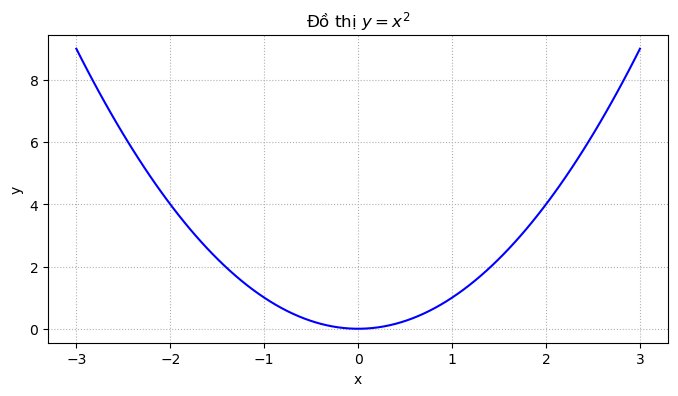

In [11]:
import matplotlib.pyplot as plt       # quy ước: plt
import numpy as np

# Ví dụ nhỏ: vẽ parabola y = x^2
x = np.linspace(-3, 3, 100)               # 100 giá trị x từ -3 đến 3
y = x ** 2                                # tính y cho từng x

plt.figure(figsize=(8, 4))                # tạo khung hình rộng 8in, cao 4in
plt.plot(x, y, 'b-')                      # vẽ đường, màu xanh ('b'), đường liền ('-')
plt.xlabel('x')                           # nhãn trục hoành
plt.ylabel('y')                           # nhãn trục tung
plt.title('Đồ thị $y = x^2$')             # tiêu đề
plt.grid(True, linestyle=':')             # bật lưới nền
plt.show()                                # hiển thị


### `plot`, `stem`, `step` -- ba cách vẽ tín hiệu

- `plot`: nối các điểm bằng đoạn thẳng (dùng cho tín hiệu liên tục hoặc gần liên tục).
- `stem`: vẽ "cọng" thẳng đứng từ trục hoành đến mỗi điểm (đúng bản chất tín hiệu rời rạc).
- `step`: đồ thị bậc thang (mô phỏng đầu ra DAC giữ giá trị).

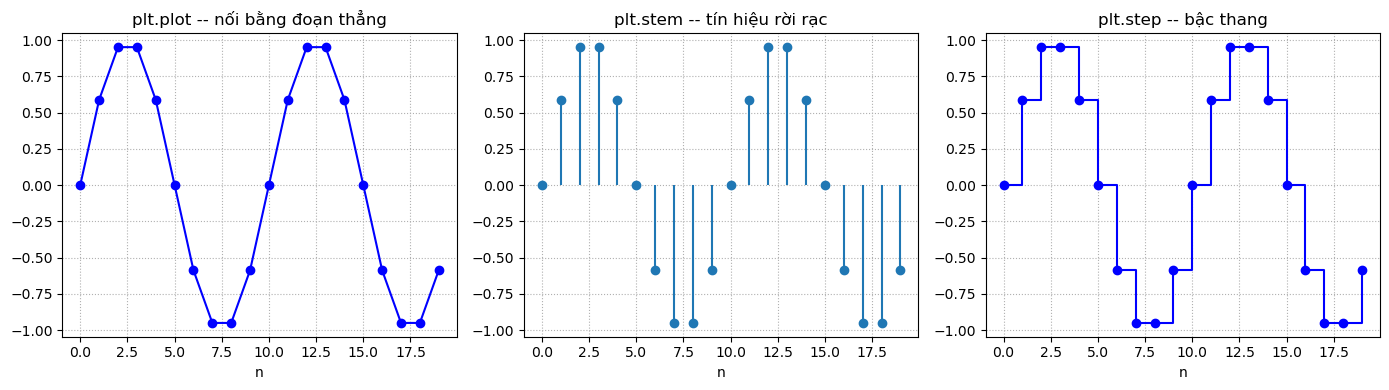

In [12]:
# Dùng 3 cách cho cùng một dãy sin ngắn
n = np.arange(0, 20)
x = np.sin(2 * np.pi * 0.1 * n)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(n, x, 'b-o')
axes[0].set_title('plt.plot -- nối bằng đoạn thẳng')
axes[0].set_xlabel('n'); axes[0].grid(True, linestyle=':')

axes[1].stem(n, x, basefmt=' ')
axes[1].set_title('plt.stem -- tín hiệu rời rạc')
axes[1].set_xlabel('n'); axes[1].grid(True, linestyle=':')

axes[2].step(n, x, where='post', color='b')
axes[2].plot(n, x, 'bo')
axes[2].set_title('plt.step -- bậc thang')
axes[2].set_xlabel('n'); axes[2].grid(True, linestyle=':')

plt.tight_layout(); plt.show()


### Tóm tắt matplotlib

| Việc | Lệnh |
|---|---|
| Mở khung | `plt.figure(figsize=(8, 4))` |
| Vẽ đường | `plt.plot(x, y, 'b-')` |
| Vẽ stem | `plt.stem(n, x)` |
| Nhãn trục | `plt.xlabel('...'); plt.ylabel('...')` |
| Tiêu đề | `plt.title('...')` |
| Lưới | `plt.grid(True)` |
| Nhiều ô | `fig, axes = plt.subplots(2, 2)` |
| Hiển thị | `plt.show()` |

---

## A.5 -- Toán cơ sở cho DSP

### A.5.1 -- Radian vs độ

Góc có hai đơn vị:
- **Độ** (degree): vòng tròn đầy đủ = $360^\circ$.
- **Radian** (rad): vòng tròn đầy đủ = $2\pi \approx 6.283$ rad.

Quan hệ: $\text{radian} = \text{độ} \times \dfrac{\pi}{180}$.

**DSP luôn dùng radian** vì công thức toán gọn hơn.

### A.5.2 -- Hàm sin và cos

Nếu $\theta$ là góc (tính bằng radian):

- $\cos(\theta)$: toạ độ x của điểm trên vòng tròn đơn vị ứng với góc $\theta$.
- $\sin(\theta)$: toạ độ y của điểm đó.

**Giá trị đặc biệt**:

| $\theta$ | 0 | $\pi/6$ | $\pi/4$ | $\pi/3$ | $\pi/2$ | $\pi$ |
|---|---|---|---|---|---|---|
| $\cos$ | 1 | $\frac{\sqrt{3}}{2}$ | $\frac{\sqrt{2}}{2}$ | $\frac{1}{2}$ | 0 | $-1$ |
| $\sin$ | 0 | $\frac{1}{2}$ | $\frac{\sqrt{2}}{2}$ | $\frac{\sqrt{3}}{2}$ | 1 | 0 |

**Tính chất quan trọng**:
- Tuần hoàn chu kỳ $2\pi$: $\cos(\theta + 2\pi) = \cos(\theta)$.
- $\cos$ là hàm **chẵn**: $\cos(-\theta) = \cos(\theta)$.
- $\sin$ là hàm **lẻ**: $\sin(-\theta) = -\sin(\theta)$.

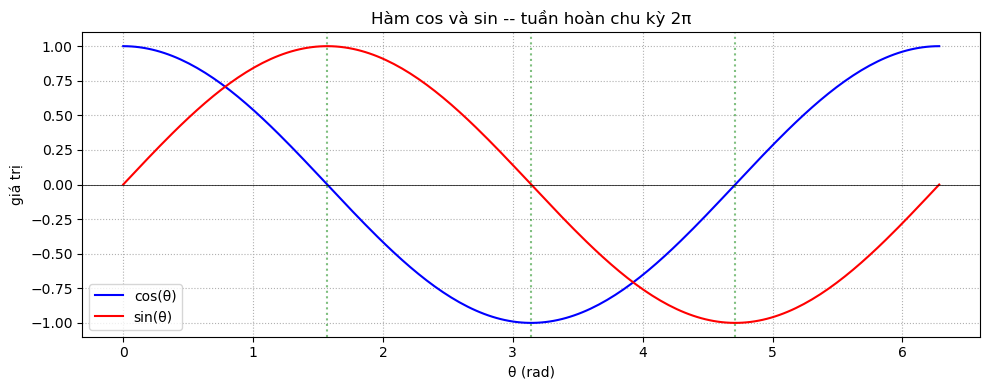

In [13]:
# Vẽ cos và sin trên [0, 2*pi]
theta = np.linspace(0, 2*np.pi, 200)

plt.figure(figsize=(10, 4))
plt.plot(theta, np.cos(theta), 'b-', label='cos(θ)')
plt.plot(theta, np.sin(theta), 'r-', label='sin(θ)')
plt.axhline(0, color='k', linewidth=0.5)
plt.axvline(np.pi/2, color='g', linestyle=':', alpha=0.5)
plt.axvline(np.pi,   color='g', linestyle=':', alpha=0.5)
plt.axvline(3*np.pi/2, color='g', linestyle=':', alpha=0.5)
plt.xlabel('θ (rad)'); plt.ylabel('giá trị')
plt.title('Hàm cos và sin -- tuần hoàn chu kỳ 2π')
plt.legend(); plt.grid(True, linestyle=':')
plt.tight_layout(); plt.show()


### A.5.3 -- Tín hiệu sin rời rạc

Một dãy sin có dạng:

$$x[n] = A \cos(2\pi f n + \phi)$$

- $A$: **biên độ** (amplitude) -- mức cao nhất/thấp nhất.
- $f$: **tần số chuẩn hoá** (normalized frequency) -- bao nhiêu chu kỳ trong 1 mẫu.
- $\phi$: **pha** (phase) -- điểm bắt đầu trong chu kỳ.

**Ví dụ**: $f = 0.1$ có nghĩa là cứ 10 mẫu thì lặp lại 1 lần (chu kỳ $N_0 = 1/f = 10$).

### A.5.4 -- Hàm mũ $e^x$

$e \approx 2.71828...$ -- một hằng số đặc biệt trong toán học. Hàm $e^x$ có đồ thị tăng rất nhanh khi $x>0$ và giảm về 0 khi $x<0$.

**Công thức Euler** (cực kỳ quan trọng):

$$e^{j\theta} = \cos\theta + j\sin\theta$$

trong đó $j = \sqrt{-1}$ là **đơn vị ảo** (MATLAB và Python dùng `j` thay vì $i$ như sách toán).

### A.5.5 -- Số phức trong Python

In [14]:
# Số phức trong Python: dùng hậu tố j
z = 2 + 3j
print('z =', z)
print('Phần thực:', z.real)         # 2.0
print('Phần ảo:  ', z.imag)         # 3.0
print('Modulus |z|:', abs(z))       # sqrt(4+9) = sqrt(13)

# Công thức Euler
theta = np.pi / 3
euler = np.exp(1j * theta)
print(f'\\nexp(j*pi/3) = {euler}')
print(f'cos(pi/3) + j*sin(pi/3) = {np.cos(theta) + 1j*np.sin(theta)}')
# -> hai số bằng nhau, xác nhận công thức Euler

# Mảng số phức
n = np.arange(0, 10)
x = np.exp(1j * 0.5 * n)     # mỗi x[n] = e^(j*0.5*n) là một số phức
print('\\nDãy mũ phức x[n]:')
print(x[:3])                  # in 3 phần tử đầu


z = (2+3j)
Phần thực: 2.0
Phần ảo:   3.0
Modulus |z|: 3.605551275463989
\nexp(j*pi/3) = (0.5000000000000001+0.8660254037844386j)
cos(pi/3) + j*sin(pi/3) = (0.5000000000000001+0.8660254037844386j)
\nDãy mũ phức x[n]:
[1.        +0.j         0.87758256+0.47942554j 0.54030231+0.84147098j]


---

## A.6 -- Bảng ánh xạ MATLAB → Python

Nếu bạn đã biết MATLAB, bảng dưới giúp bạn chuyển sang Python nhanh chóng.

| MATLAB | Python (numpy) |
|---|---|
| `n = 1:10` | `n = np.arange(1, 11)` |
| `n = -10:20` | `n = np.arange(-10, 21)` |
| `zeros(1, 10)` | `np.zeros(10)` |
| `ones(1, 5)` | `np.ones(5)` |
| `length(x)` | `len(x)` hoặc `x.size` |
| `x.^2` | `x ** 2` |
| `x .* y` | `x * y` |
| `x(1)` (phần tử đầu) | `x[0]` |
| `x(end)` | `x[-1]` |
| `x(1:5)` | `x[0:5]` |
| `stem(n, x)` | `plt.stem(n, x)` |
| `plot(n, x)` | `plt.plot(n, x)` |
| `rand(1, 100)` | `np.random.rand(100)` |
| `randn(1, 75)` | `np.random.randn(75)` |
| `real(x), imag(x)` | `x.real, x.imag` |
| `i` hoặc `1i` | `1j` |
| `subplot(2,1,1)` | `plt.subplot(2,1,1)` |
| `title('...')` | `plt.title('...')` |

Điểm khác biệt đáng chú ý:
- **MATLAB bắt đầu từ 1**, Python bắt đầu từ **0**.
- **MATLAB phân biệt `*` (ma trận) và `.*` (pointwise)**, Python numpy `*` luôn pointwise.
- **MATLAB tự động hiển thị kết quả**, Python cần `print()`.

---

**Hết Phần A.** Bây giờ bạn đã đủ nền tảng để làm các Project của Lab 1.


# PHẦN B -- CÁC THÍ NGHIỆM LAB 1

## Khởi động môi trường cho toàn bộ Phần B

Chạy ô dưới trước khi chạy bất kỳ ô nào trong Phần B.

In [15]:
# Nhập các thư viện chính
import numpy as np                       # tính toán mảng
import matplotlib.pyplot as plt          # vẽ đồ thị
from scipy import signal                 # hàm square, sawtooth, spectrogram, firwin
from scipy.fft import fft, fftfreq       # biến đổi Fourier rời rạc

# Cố định hạt giống ngẫu nhiên để các lần chạy cho KẾT QUẢ GIỐNG NHAU
np.random.seed(42)

# Cấu hình chung cho biểu đồ
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid']      = True
plt.rcParams['font.size']      = 11

# Hai hàm tiện ích sẽ dùng lại nhiều lần
def stem_plot(n, x, title='', xlabel='n', ylabel='x[n]',
              xlim=None, ylim=None, color='C0'):
    """Vẽ stem cho dãy rời rạc (n, x)."""
    fig, ax = plt.subplots(figsize=(10, 3.8))
    ml, sl, bl = ax.stem(n, x, basefmt=' ', linefmt=color+'-', markerfmt=color+'o')
    ml.set_markersize(5)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.axhline(0, color='k', linewidth=0.5)
    if xlim: ax.set_xlim(xlim)
    if ylim: ax.set_ylim(ylim)
    ax.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout(); plt.show()

def compare_stems(data_list, suptitle='', figsize=(12, 8)):
    """Vẽ nhiều stem-plot xếp dọc.

    data_list: list của tuple (n, x, tiêu_đề)
    """
    N = len(data_list)
    fig, axes = plt.subplots(N, 1, figsize=figsize, sharex=False)
    if N == 1: axes = [axes]
    for i, (n, x, t) in enumerate(data_list):
        ml, sl, bl = axes[i].stem(n, x, basefmt=' ',
                                  linefmt=f'C{i%10}-', markerfmt=f'C{i%10}o')
        ml.set_markersize(4)
        axes[i].set_title(t, fontsize=11)
        axes[i].set_xlabel('n'); axes[i].set_ylabel('Amp.')
        axes[i].grid(True, linestyle=':', alpha=0.6)
        axes[i].axhline(0, color='k', linewidth=0.4)
    if suptitle:
        fig.suptitle(suptitle, fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()

print('Sẵn sàng. Bạn có thể chạy các Project từ 1.1 đến 1.8.')


Sẵn sàng. Bạn có thể chạy các Project từ 1.1 đến 1.8.


---

## Project 1.1 -- Xung đơn vị và bậc thang đơn vị

### Tại sao cần biết?

**Xung đơn vị** $\delta[n]$ giống như "nốt chấm" trong bản nhạc -- mỗi bài nhạc phức tạp đến đâu, về bản chất đều là tập hợp các nốt chấm ở các vị trí khác nhau. Trong DSP, mọi dãy số đều có thể viết thành tổng các xung đơn vị dịch.

**Bậc thang đơn vị** $u[n]$ mô tả **sự kiện "bắt đầu"** -- giống như nhấn nút ON của đèn.

### Định nghĩa toán học

$$\delta[n] = \begin{cases} 1 & \text{nếu } n = 0 \\ 0 & \text{nếu } n \ne 0 \end{cases}, \qquad u[n] = \begin{cases} 1 & \text{nếu } n \ge 0 \\ 0 & \text{nếu } n < 0 \end{cases}$$

### Thí nghiệm mini: tạo $\delta[n]$ bằng cách thủ công

Giả sử ta muốn tạo $\delta[n]$ với $n$ chạy từ $-3$ đến $5$ (tổng 9 giá trị).

n     = [-3 -2 -1  0  1  2  3  4  5]
delta = [0. 0. 0. 1. 0. 0. 0. 0. 0.]


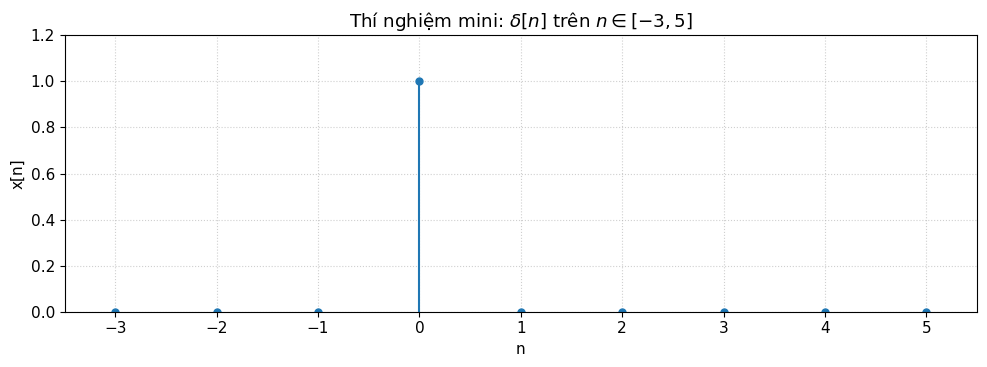

In [16]:
# Cách 1: ghép 3 đoạn bằng np.concatenate
# delta[n] = 0 với n = -3, -2, -1  (3 số 0)
# delta[0] = 1                      (1 số 1)
# delta[n] = 0 với n = 1, 2, 3, 4, 5  (5 số 0)
delta = np.concatenate([np.zeros(3), [1], np.zeros(5)])
n     = np.arange(-3, 6)                 # -3, -2, -1, 0, 1, 2, 3, 4, 5

print('n     =', n)
print('delta =', delta)

# Vẽ để nhìn trực quan
stem_plot(n, delta, title='Thí nghiệm mini: $\\delta[n]$ trên $n \\in [-3, 5]$',
          xlim=(-3.5, 5.5), ylim=(0, 1.2))


### Cách sinh $\delta[n]$ khác: dùng toán tử so sánh

In [17]:
# Cách 2: tạo một mảng 0/1 theo điều kiện
# (n == 0) trả về mảng boolean True/False, chuyển sang int -> 1/0
n = np.arange(-3, 6)
delta = (n == 0).astype(int)
print('delta =', delta)

# Cách 3: cho sẵn vị trí của 1
n = np.arange(-3, 6)
delta = np.zeros_like(n, dtype=float)    # mảng 0 cùng kích thước n
idx = np.where(n == 0)[0][0]             # tìm vị trí n == 0
delta[idx] = 1
print('delta =', delta)


delta = [0 0 0 1 0 0 0 0 0]
delta = [0. 0. 0. 1. 0. 0. 0. 0. 0.]


### Bây giờ làm 4 phiên bản cùng một lúc (Q1.1, Q1.3, Q1.4, Q1.5)

- **(a)** $\delta[n]$ -- Q1.1
- **(b)** $\delta[n-11]$ -- xung đơn vị trễ 11 mẫu -- Q1.3
- **(c)** $u[n]$ -- bậc thang -- Q1.4
- **(d)** $u[n+7]$ -- bậc thang đi trước 7 mẫu -- Q1.5

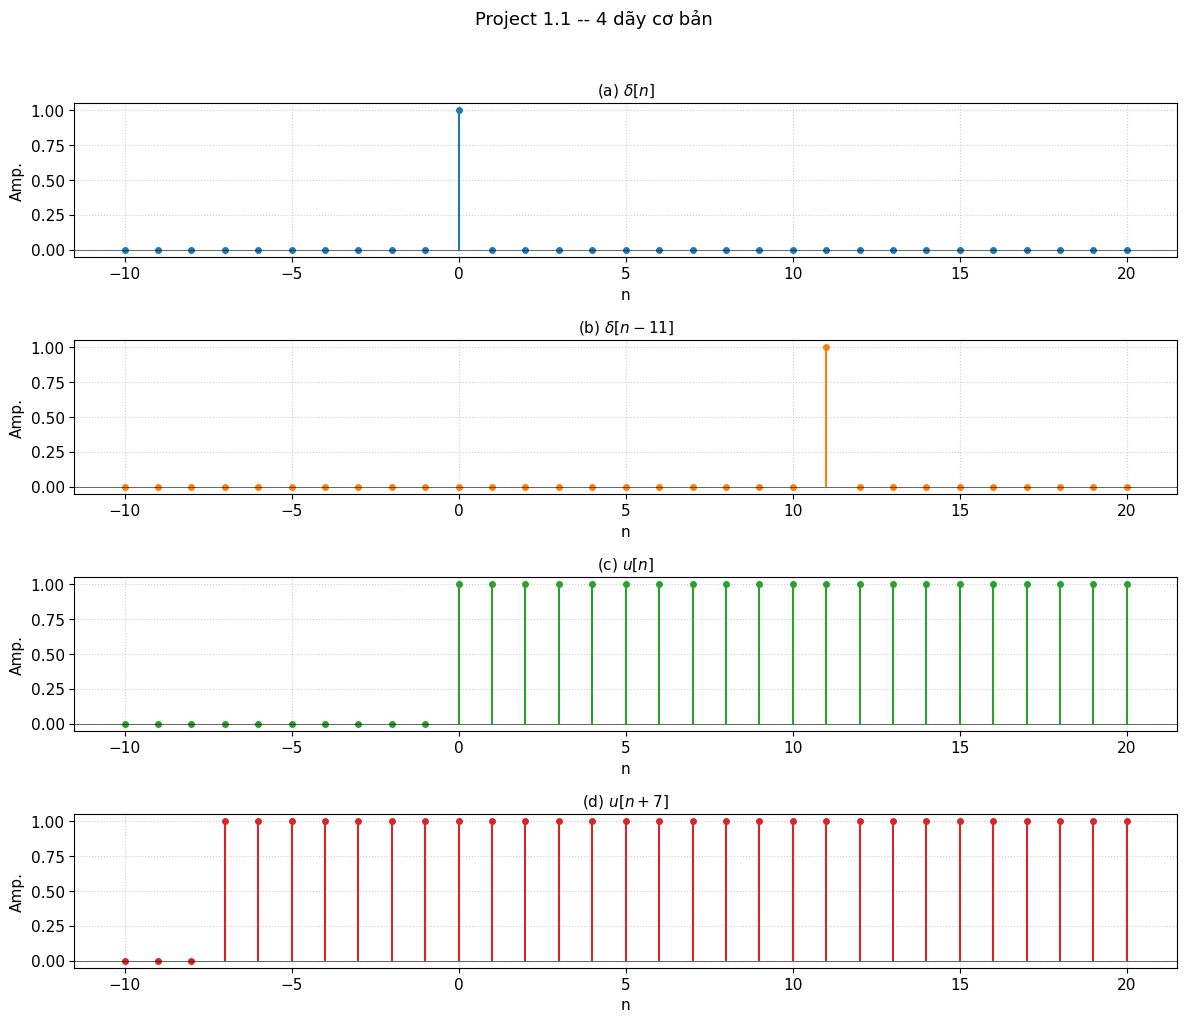

In [18]:
# Miền n = -10 đến 20 (31 chỉ số)
n = np.arange(-10, 21)

# (a) delta[n]: 1 tại n=0.
# n = -10 là index 0 của mảng. n = 0 là index 0 - (-10) = 10.
# Vậy ghép: 10 số 0 ở đầu, 1 ở giữa, 20 số 0 ở cuối (tổng 31).
delta_n = np.concatenate([np.zeros(10), [1], np.zeros(20)])

# (b) delta[n-11]: 1 tại n=11. Vị trí n=11 trong mảng là index 11-(-10) = 21.
# Ghép: 21 số 0, 1, 9 số 0 (tổng 31).
delta_shift = np.concatenate([np.zeros(21), [1], np.zeros(9)])

# (c) u[n]: 1 với n >= 0. Có 10 số 0 (cho n = -10..-1) rồi 21 số 1 (cho n = 0..20).
u_n = np.concatenate([np.zeros(10), np.ones(21)])

# (d) u[n+7] = u[m] với m = n+7. Dãy u[m] nhảy từ 0->1 tại m=0, tức là tại n = -7.
# Vị trí n = -7 trong mảng là index -7 - (-10) = 3.
# Ghép: 3 số 0, 28 số 1 (tổng 31).
u_advanced = np.concatenate([np.zeros(3), np.ones(28)])

# Vẽ cả 4 trên cùng hình
compare_stems([
    (n, delta_n,     r'(a) $\delta[n]$'),
    (n, delta_shift, r'(b) $\delta[n-11]$'),
    (n, u_n,         r'(c) $u[n]$'),
    (n, u_advanced,  r'(d) $u[n+7]$'),
], suptitle='Project 1.1 -- 4 dãy cơ bản', figsize=(12, 10))


### Q1.2 -- Công dụng các lệnh đồ thị

| MATLAB | Python | Công dụng |
|---|---|---|
| `clf` | `plt.clf()` | xoá hình hiện tại |
| `axis([a b c d])` | `plt.axis([a,b,c,d])` | giới hạn hai trục |
| `title('T')` | `plt.title('T')` | tiêu đề |
| `xlabel('X')` | `plt.xlabel('X')` | nhãn trục hoành |
| `ylabel('Y')` | `plt.ylabel('Y')` | nhãn trục tung |

### Bài tập nhỏ tự làm

1. Tạo dãy $y[n] = \delta[n] + 2\delta[n-3] + \delta[n-6]$ trên $n \in [0, 10]$ rồi vẽ.
2. Dãy $x[n] = u[n] - u[n-5]$ có hình dáng thế nào?

Gợi ý: dãy $u[n] - u[n-5]$ bằng 1 với $n = 0, 1, 2, 3, 4$ và bằng 0 chỗ khác -- tạo thành **xung vuông** độ dài 5.

---

## Project 1.2 -- Dãy mũ (Exponential)

### Tại sao cần biết?

**Dãy mũ phức** $K e^{cn}$ có thể coi là "nguyên tử" của DSP:
- Nó chứa cả **biên độ tăng/giảm** (nhờ phần thực của $c$).
- Và **dao động sin** (nhờ phần ảo của $c$).
- Biến đổi **Fourier** và **Z** đều xây trên ý tưởng "mọi dãy = tổng các dãy mũ phức".

### Công thức

$$x[n] = K\, e^{cn}, \qquad c = \sigma + j\omega_0$$

Dùng công thức Euler $e^{j\theta} = \cos\theta + j\sin\theta$:

$$x[n] = K\, e^{\sigma n}\, \big[\cos(\omega_0 n) + j\sin(\omega_0 n)\big]$$

- **Phần thực**: $K e^{\sigma n} \cos(\omega_0 n)$ -- sóng cos có **bao** $K e^{\sigma n}$.
- **Phần ảo**: $K e^{\sigma n} \sin(\omega_0 n)$ -- sóng sin có cùng bao.

### Thí nghiệm mini: $e^x$ vs $e^{-x}$

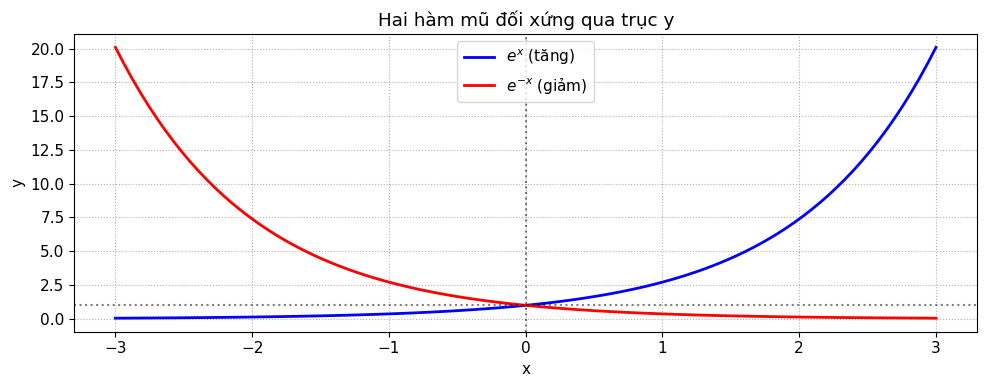

Tại x=0, cả hai hàm đều bằng 1.
Với x > 0: e^x tăng nhanh, e^(-x) giảm nhanh.


In [19]:
# Vẽ đồ thị hàm e^x và e^(-x)
x = np.linspace(-3, 3, 100)
y1 = np.exp(x)         # e^x: tăng nhanh khi x > 0
y2 = np.exp(-x)        # e^(-x): giảm nhanh khi x > 0

plt.figure(figsize=(10, 4))
plt.plot(x, y1, 'b-', label='$e^x$ (tăng)', linewidth=2)
plt.plot(x, y2, 'r-', label='$e^{-x}$ (giảm)', linewidth=2)
plt.axhline(1, color='k', linestyle=':', alpha=0.5)    # đường y=1
plt.axvline(0, color='k', linestyle=':', alpha=0.5)    # đường x=0
plt.xlabel('x'); plt.ylabel('y')
plt.title('Hai hàm mũ đối xứng qua trục y')
plt.legend(); plt.grid(True, linestyle=':')
plt.tight_layout(); plt.show()
print('Tại x=0, cả hai hàm đều bằng 1.')
print('Với x > 0: e^x tăng nhanh, e^(-x) giảm nhanh.')


### P1_2 -- Dãy mũ phức với $c = -\tfrac{1}{12} + j\tfrac{\pi}{6}$

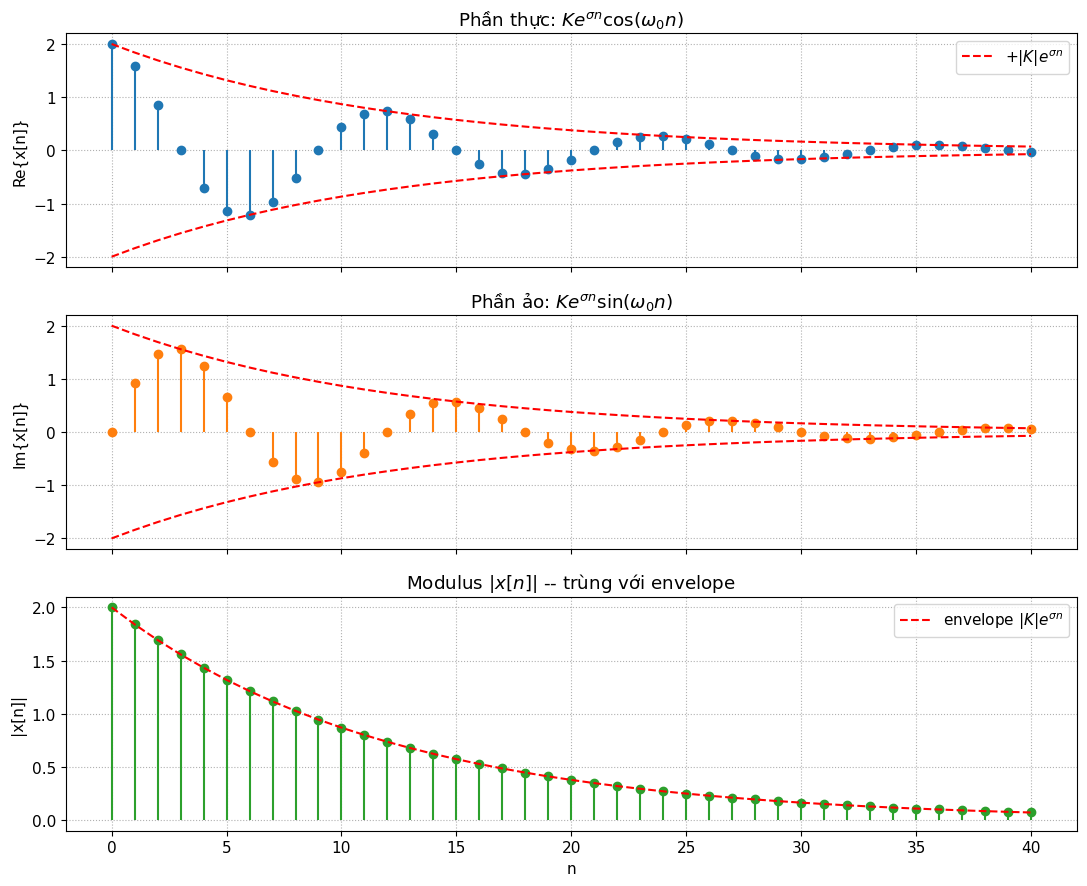

In [20]:
# Tham số
sigma  = -1/12                           # phần thực: âm -> suy giảm
omega0 = np.pi/6                         # phần ảo: tần số dao động
c      = sigma + 1j * omega0             # số phức c = sigma + j*omega0
K      = 2                               # biên độ
n      = np.arange(0, 41)                # n = 0, 1, ..., 40

# Tính dãy mũ phức theo vector n
# np.exp hoạt động trên mảng phức: mỗi phần tử được tính riêng
x = K * np.exp(c * n)

# Bao envelope: |K| * exp(sigma*n)
envelope = abs(K) * np.exp(sigma * n)

# Vẽ phần thực và phần ảo kèm bao
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

# Phần thực
axes[0].stem(n, x.real, basefmt=' ', linefmt='C0-', markerfmt='C0o')
axes[0].plot(n,  envelope, 'r--', label='$+|K|e^{\\sigma n}$', linewidth=1.5)
axes[0].plot(n, -envelope, 'r--', linewidth=1.5)
axes[0].set_title('Phần thực: $K e^{\\sigma n}\\cos(\\omega_0 n)$')
axes[0].set_ylabel('Re{x[n]}'); axes[0].legend()
axes[0].grid(True, linestyle=':')

# Phần ảo
axes[1].stem(n, x.imag, basefmt=' ', linefmt='C1-', markerfmt='C1o')
axes[1].plot(n,  envelope, 'r--', linewidth=1.5)
axes[1].plot(n, -envelope, 'r--', linewidth=1.5)
axes[1].set_title('Phần ảo: $K e^{\\sigma n}\\sin(\\omega_0 n)$')
axes[1].set_ylabel('Im{x[n]}')
axes[1].grid(True, linestyle=':')

# Modulus = envelope
axes[2].stem(n, np.abs(x), basefmt=' ', linefmt='C2-', markerfmt='C2o')
axes[2].plot(n, envelope, 'r--', label='envelope $|K|e^{\\sigma n}$', linewidth=1.5)
axes[2].set_title('Modulus $|x[n]|$ -- trùng với envelope')
axes[2].set_xlabel('n'); axes[2].set_ylabel('|x[n]|'); axes[2].legend()
axes[2].grid(True, linestyle=':')

plt.tight_layout(); plt.show()


### Đường xoắn ốc 3-D trong không gian phức

Nếu vẽ $x[n]$ trong không gian 3 chiều $(n, \text{Re}, \text{Im})$, ta thấy một đường **xoắn ốc** tắt dần.

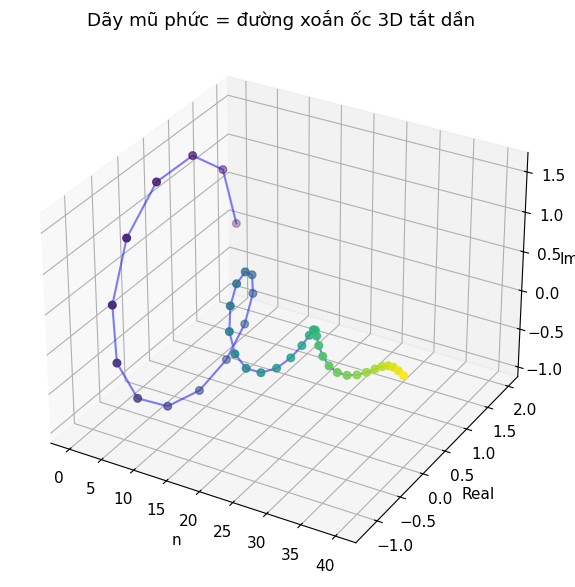

In [21]:
# Vẽ xoắn ốc 3D
from mpl_toolkits.mplot3d import Axes3D                # cần để vẽ 3D

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot(n, x.real, x.imag, 'b-', alpha=0.5)
ax.scatter(n, x.real, x.imag, c=n, cmap='viridis', s=30)
ax.set_xlabel('n'); ax.set_ylabel('Real'); ax.set_zlabel('Imag')
ax.set_title('Dãy mũ phức = đường xoắn ốc 3D tắt dần')
plt.tight_layout(); plt.show()


### Q1.6 -- Q1.10

- **Q1.6**: đồ thị đã vẽ ở trên.
- **Q1.7**: tốc độ tăng/giảm điều khiển bởi $\sigma$ (phần thực của $c$). Biên độ là $K$.
- **Q1.8**: đổi $\sigma = +1/12$ → dãy **bùng nổ** thay vì suy giảm.
- **Q1.9**: `x.real` và `x.imag` trích phần thực/ảo.
- **Q1.10**: `subplot(m,n,k)` chia figure làm $m \times n$ ô, vẽ ô thứ $k$.

### P1_3 -- Dãy mũ **thực** (không có phần ảo)

$$x[n] = K \cdot a^n$$

- Nếu $a > 1$: **tăng** luỹ thừa.
- Nếu $0 < a < 1$: **giảm** luỹ thừa.
- Nếu $a = 1$: hằng số.
- Nếu $a < 0$: đan dấu (oscillate).

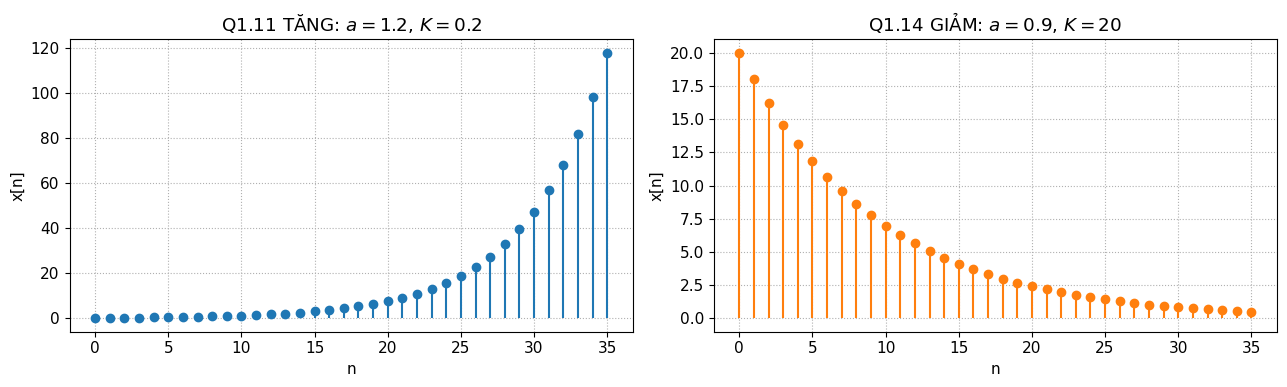

Năng lượng Q1.11: 4.5673e+04   (PDF gốc: 4.5673e+04)
Năng lượng Q1.14: 2.1042e+03   (PDF gốc: 2.1042e+03)


In [22]:
# Q1.11: a=1.2 (tăng), K=0.2
n  = np.arange(0, 36)                    # 36 điểm từ 0 đến 35
a1 = 1.2
K1 = 0.2
x1 = K1 * (a1 ** n)                      # x[n] = 0.2 * 1.2^n

# Q1.14: a=0.9 (giảm), K=20
a2 = 0.9
K2 = 20
x2 = K2 * (a2 ** n)

# Vẽ song song
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].stem(n, x1, basefmt=' ', linefmt='C0-', markerfmt='C0o')
axes[0].set_title(f'Q1.11 TĂNG: $a={a1}$, $K={K1}$')
axes[0].set_xlabel('n'); axes[0].set_ylabel('x[n]'); axes[0].grid(True, linestyle=':')

axes[1].stem(n, x2, basefmt=' ', linefmt='C1-', markerfmt='C1o')
axes[1].set_title(f'Q1.14 GIẢM: $a={a2}$, $K={K2}$')
axes[1].set_xlabel('n'); axes[1].set_ylabel('x[n]'); axes[1].grid(True, linestyle=':')

plt.tight_layout(); plt.show()

# Năng lượng (Q1.16)
E1 = np.sum(x1 ** 2)                     # tổng bình phương
E2 = np.sum(x2 ** 2)
print(f'Năng lượng Q1.11: {E1:.4e}   (PDF gốc: 4.5673e+04)')
print(f'Năng lượng Q1.14: {E2:.4e}   (PDF gốc: 2.1042e+03)')


### Q1.12 -- Q1.16

- Q1.12: tốc độ tăng/giảm là $a$. Biên độ là $K$.
- Q1.13: MATLAB `^` = luỹ thừa ma trận, `.^` = pointwise. Numpy `**` luôn pointwise.
- Q1.14: đã vẽ ở trên.
- Q1.15: độ dài dãy 36, điều khiển bởi `np.arange(0, 36)`. Để dài 100 dùng `np.arange(0, 100)`.
- Q1.16: năng lượng đã in ở trên.

### Ứng dụng thực tế

- **Dây đàn guitar**: sau khi gảy, biên độ tắt dần theo $e^{-t/\tau}$ -- đó là dãy mũ thực.
- **Pin Lithium**: điện áp giảm theo hàm mũ khi phóng điện.
- **Phân rã phóng xạ**: $N(t) = N_0 e^{-\lambda t}$.

### Bài tập nhỏ

Tính tổng của dãy mũ $x[n] = (0.5)^n$ với $n = 0, 1, 2, ..., 10$. So sánh với công thức tổng cấp số nhân $S = \frac{1-a^{N+1}}{1-a}$ khi $N \to \infty$.

---

## Project 1.3 -- Dãy sin (Sinusoidal)

### Tại sao cần biết?

Tín hiệu sin là **DNA** của mọi âm thanh có giai điệu. Một dây đàn gảy cho ra sóng gần sin. Giọng nguyên âm "a" trong tiếng Việt là tổng của **vài chục** sóng sin ở tần số bội. Nhận dạng giọng nói, âm nhạc, điều biên radio -- tất cả xây trên sin.

### Công thức chuẩn

$$x[n] = A \cos(2\pi f n - \phi)$$

- **A**: biên độ (độ cao của sóng).
- **f**: tần số chuẩn hoá (cycles/sample). Dải ý nghĩa $-1/2 \le f \le 1/2$.
- **$\phi$**: pha khởi đầu (radian).
- **Chu kỳ cơ bản**: $N_0 = 1/f$.

Lưu ý dấu trừ trước $\phi$: đây là cách MATLAB gốc viết, Python ta phải đổi pha dương → trị âm khi cần.

### Thí nghiệm mini: tần số khác nhau tạo đồ thị khác nhau thế nào?

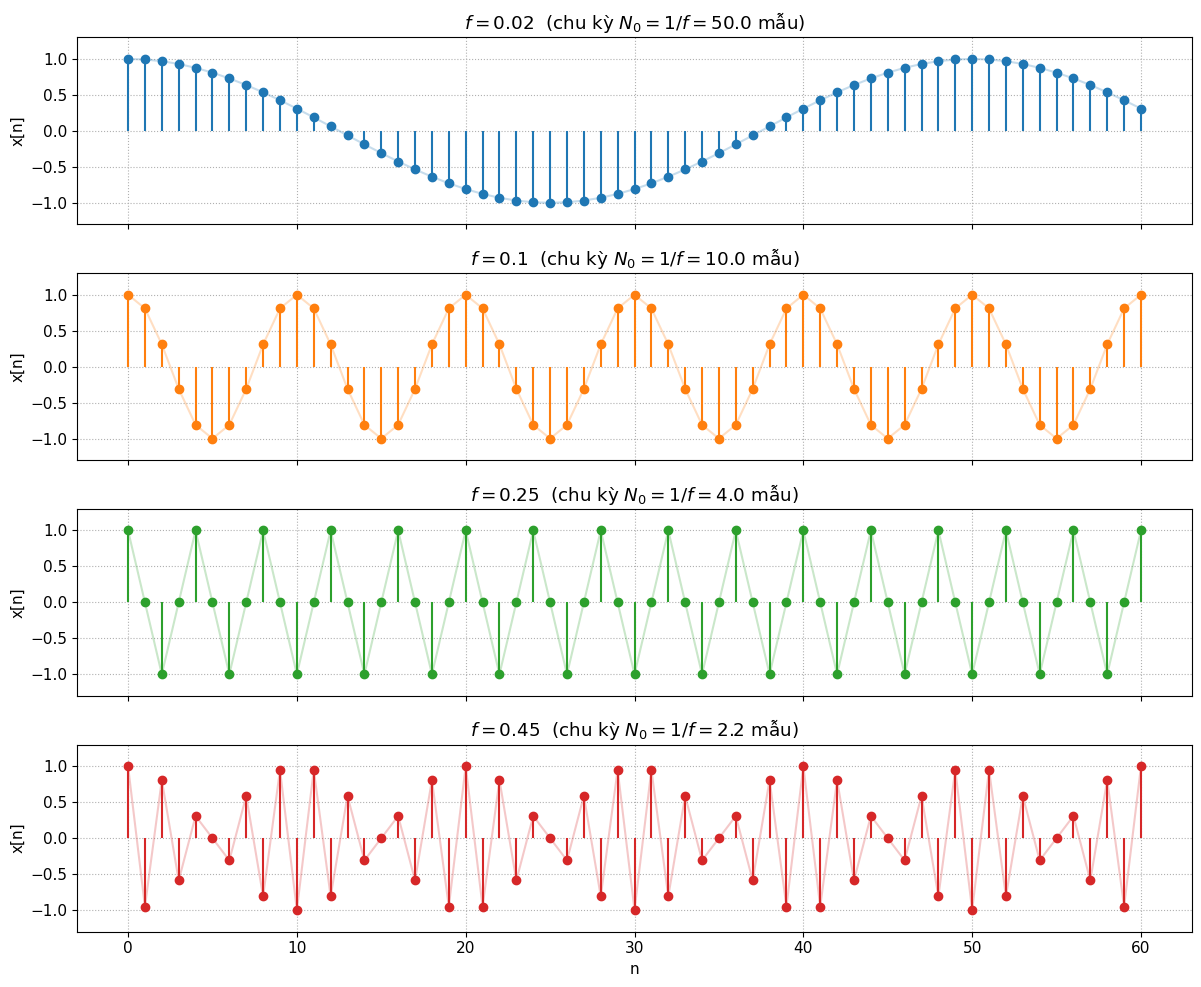

In [23]:
# So sánh 4 tần số: f = 0.02 (chậm) đến f = 0.45 (gần Nyquist)
n = np.arange(0, 61)                          # 61 mẫu
freqs = [0.02, 0.10, 0.25, 0.45]              # 4 giá trị tần số

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
for i, f in enumerate(freqs):
    x = np.cos(2 * np.pi * f * n)             # tạo dãy cos
    axes[i].stem(n, x, basefmt=' ', linefmt=f'C{i}-', markerfmt=f'C{i}o')
    axes[i].plot(n, x, color=f'C{i}', alpha=0.25)   # đường mờ nối các chấm
    axes[i].set_title(f'$f = {f}$  (chu kỳ $N_0 = 1/f = {1/f:.1f}$ mẫu)')
    axes[i].set_ylabel('x[n]'); axes[i].set_ylim(-1.3, 1.3)
    axes[i].grid(True, linestyle=':')
axes[-1].set_xlabel('n')
plt.tight_layout(); plt.show()


**Quan sát quan trọng**: khi $f$ gần $0.5$ (biên Nyquist), mỗi chu kỳ chỉ còn ~2 mẫu → tín hiệu **trông như nhiễu** dù thực ra vẫn là sin đều. Đây là lý do **định lý lấy mẫu** nói tần số gốc phải $< F_s/2$.

### P1_4 -- Tham số mặc định (Q1.17)

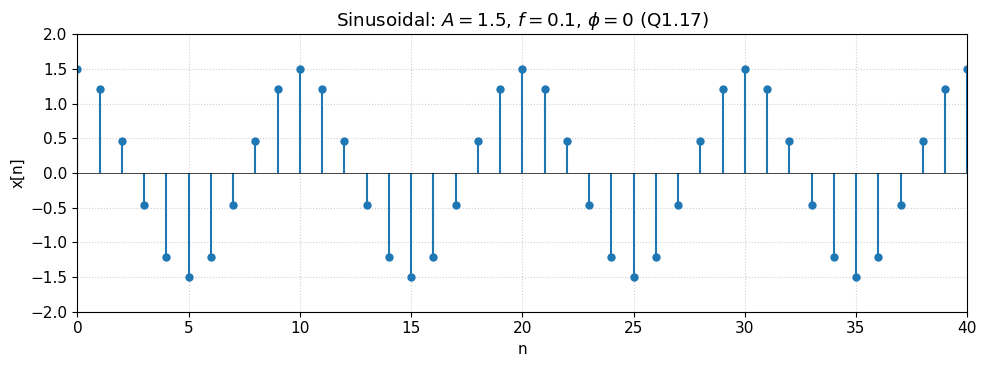

Công suất trung bình 10 mẫu đầu: 1.1250   (PDF: 1.1250)
Lý thuyết cho cos đầy đủ chu kỳ: A^2/2 = 1.1250


In [24]:
# P1_4
n     = np.arange(0, 41)                     # 41 mẫu
f     = 0.1                                  # tần số
phase = 0                                    # pha 0
A     = 1.5                                  # biên độ
arg   = 2 * np.pi * f * n - phase            # đối số của cos
x     = A * np.cos(arg)

stem_plot(n, x, title=f'Sinusoidal: $A={A}$, $f={f}$, $\\phi={phase}$ (Q1.17)',
          xlim=(0, 40), ylim=(-2, 2))

# Q1.20: công suất trung bình 10 mẫu đầu
p10 = np.sum(x[:10] ** 2) / 10
print(f'Công suất trung bình 10 mẫu đầu: {p10:.4f}   (PDF: 1.1250)')
print(f'Lý thuyết cho cos đầy đủ chu kỳ: A^2/2 = {A**2/2:.4f}')


### Q1.22 -- Hiện tượng Cyclic Frequency

Trong máy tính, các tần số $f$, $f+1$, $f+2$, ..., $1-f$, ... **tạo ra cùng một dãy rời rạc**. Lý do: $\cos(2\pi(f+k)n) = \cos(2\pi f n + 2\pi k n) = \cos(2\pi f n)$ với $k, n$ nguyên.

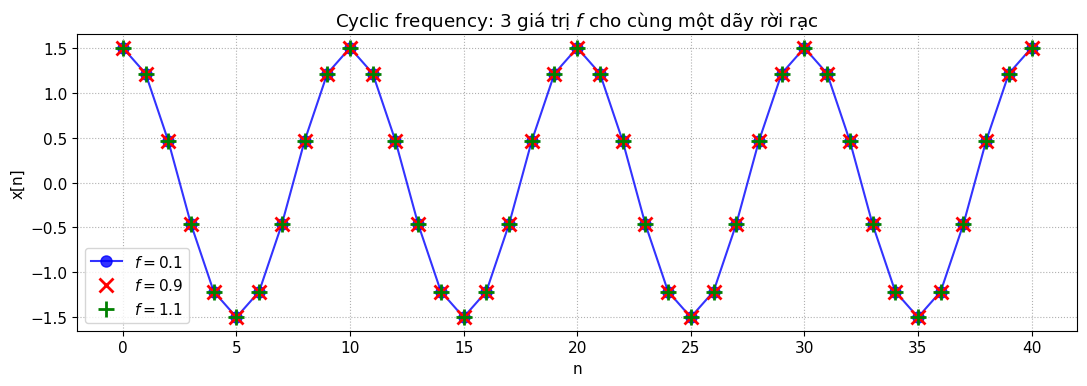

Max sai số |x_0.1 - x_0.9| = 3.01e-14
Max sai số |x_0.1 - x_1.1| = 4.42e-14
-> ~0 (sai số máy tính). Ba đồ thị trùng khít hoàn toàn.


In [25]:
# Chứng minh bằng hình: vẽ chồng 3 dãy f=0.1, f=0.9, f=1.1
n = np.arange(0, 41); A = 1.5
x_01 = A * np.cos(2*np.pi * 0.1 * n)
x_09 = A * np.cos(2*np.pi * 0.9 * n)
x_11 = A * np.cos(2*np.pi * 1.1 * n)

plt.figure(figsize=(11, 4))
plt.plot(n, x_01, 'bo-', markersize=8, label='$f=0.1$', alpha=0.8)
plt.plot(n, x_09, 'rx',  markersize=10, label='$f=0.9$', markeredgewidth=2)
plt.plot(n, x_11, 'g+',  markersize=12, label='$f=1.1$', markeredgewidth=2)
plt.xlabel('n'); plt.ylabel('x[n]')
plt.title('Cyclic frequency: 3 giá trị $f$ cho cùng một dãy rời rạc')
plt.legend(); plt.grid(True, linestyle=':')
plt.tight_layout(); plt.show()

print(f'Max sai số |x_0.1 - x_0.9| = {np.max(np.abs(x_01 - x_09)):.2e}')
print(f'Max sai số |x_0.1 - x_1.1| = {np.max(np.abs(x_01 - x_11)):.2e}')
print('-> ~0 (sai số máy tính). Ba đồ thị trùng khít hoàn toàn.')


### Minh hoạ aliasing: sóng 700 Hz lấy mẫu ở 1000 Hz hiện ra 300 Hz

Nếu tín hiệu analog có tần số $f_0$ vượt quá $F_s/2$, nó sẽ "giả dạng" thành tần số $|f_0 - kF_s|$ với $k$ nguyên. Đây là một trong những "cạm bẫy" lớn nhất của DSP thực tế.

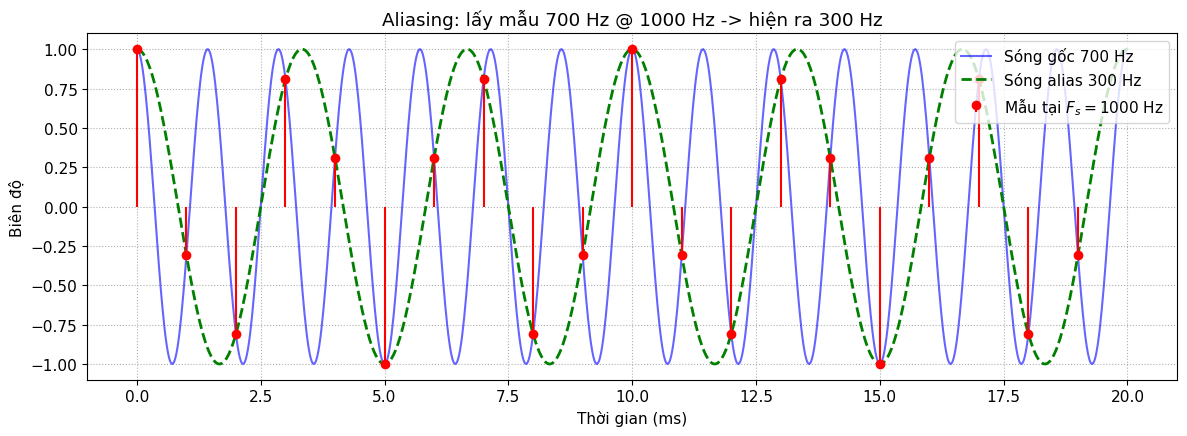

Tần số alias = |700 - 1000| = 300 Hz
Các chấm đỏ (mẫu) NẰM ĐÚNG TRÊN CẢ HAI đường xanh (700 Hz) và xanh lá (300 Hz).
-> Từ các mẫu, không thể phân biệt tín hiệu gốc là 700 hay 300 Hz.


In [26]:
Fs     = 1000                               # tần số lấy mẫu (Hz)
f_true = 700                                # tần số thực của tín hiệu analog

# Mô phỏng sóng analog: 1000 điểm trong 20 ms (dày đủ để nhìn như liên tục)
t_cont = np.linspace(0, 0.02, 1000)
x_cont = np.cos(2*np.pi * f_true * t_cont)

# Các mẫu thực sự ghi lại bởi máy tính (tại Fs=1000 Hz)
n = np.arange(0, int(0.02 * Fs))            # 20 mẫu trong 20 ms
t_samp = n / Fs
x_samp = np.cos(2*np.pi * f_true * t_samp)

# Sóng ALIAS (300 Hz) mà mắt ta "thấy" từ các mẫu
f_alias = abs(f_true - Fs)                  # |700 - 1000| = 300
x_alias = np.cos(2*np.pi * f_alias * t_cont)

plt.figure(figsize=(12, 4.5))
plt.plot(t_cont*1000, x_cont,  'b-',  alpha=0.6, label=f'Sóng gốc {f_true} Hz')
plt.plot(t_cont*1000, x_alias, 'g--', linewidth=2, label=f'Sóng alias {f_alias} Hz')
plt.stem(t_samp*1000, x_samp, basefmt=' ', linefmt='r-', markerfmt='ro',
         label=f'Mẫu tại $F_s={Fs}$ Hz')
plt.xlabel('Thời gian (ms)'); plt.ylabel('Biên độ')
plt.title('Aliasing: lấy mẫu 700 Hz @ 1000 Hz -> hiện ra 300 Hz')
plt.legend(loc='upper right'); plt.grid(True, linestyle=':')
plt.tight_layout(); plt.show()

print(f'Tần số alias = |{f_true} - {Fs}| = {f_alias} Hz')
print('Các chấm đỏ (mẫu) NẰM ĐÚNG TRÊN CẢ HAI đường xanh (700 Hz) và xanh lá (300 Hz).')
print('-> Từ các mẫu, không thể phân biệt tín hiệu gốc là 700 hay 300 Hz.')


### Q1.23 -- $N=50$, $f=0.08$, $A=2.5$, $\phi=90^\circ$

Chú ý: pha 90° sang radian là $\pi/2$. Vì code gốc dùng `arg = 2*pi*f*n - phase`, ta phải đặt `phase = -90*pi/180 = -pi/2` để đạt hiệu ứng $+\pi/2$.

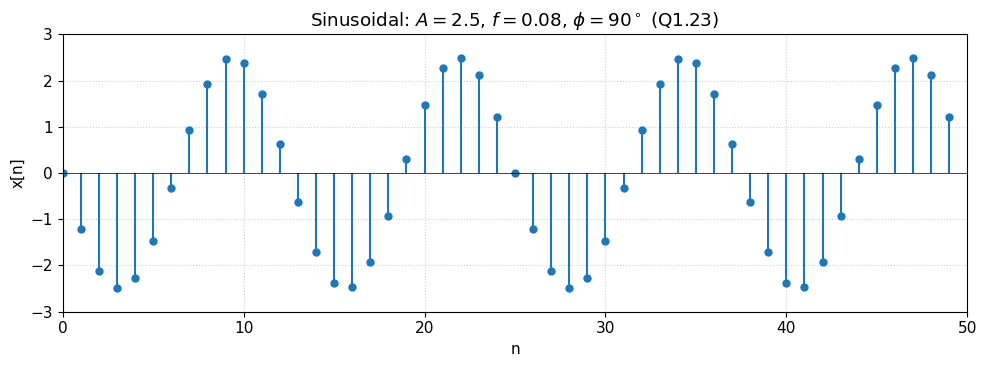

1/f = 12.5 -> không nguyên, nên chu kỳ ĐẦY ĐỦ là 25 mẫu (2 chu kỳ cos).


In [27]:
n     = np.arange(0, 50)
f     = 0.08
phase = -90 * np.pi / 180          # 90 độ -> -pi/2 (do dấu trừ trong arg)
A     = 2.5
arg   = 2 * np.pi * f * n - phase
x     = A * np.cos(arg)

stem_plot(n, x, title=f'Sinusoidal: $A={A}$, $f={f}$, $\\phi=90^\\circ$ (Q1.23)',
          xlim=(0, 50), ylim=(-3, 3))
print(f'1/f = {1/f} -> không nguyên, nên chu kỳ ĐẦY ĐỦ là 25 mẫu (2 chu kỳ cos).')


### Q1.24 và Q1.25 -- `plot` và `step` thay `stem`

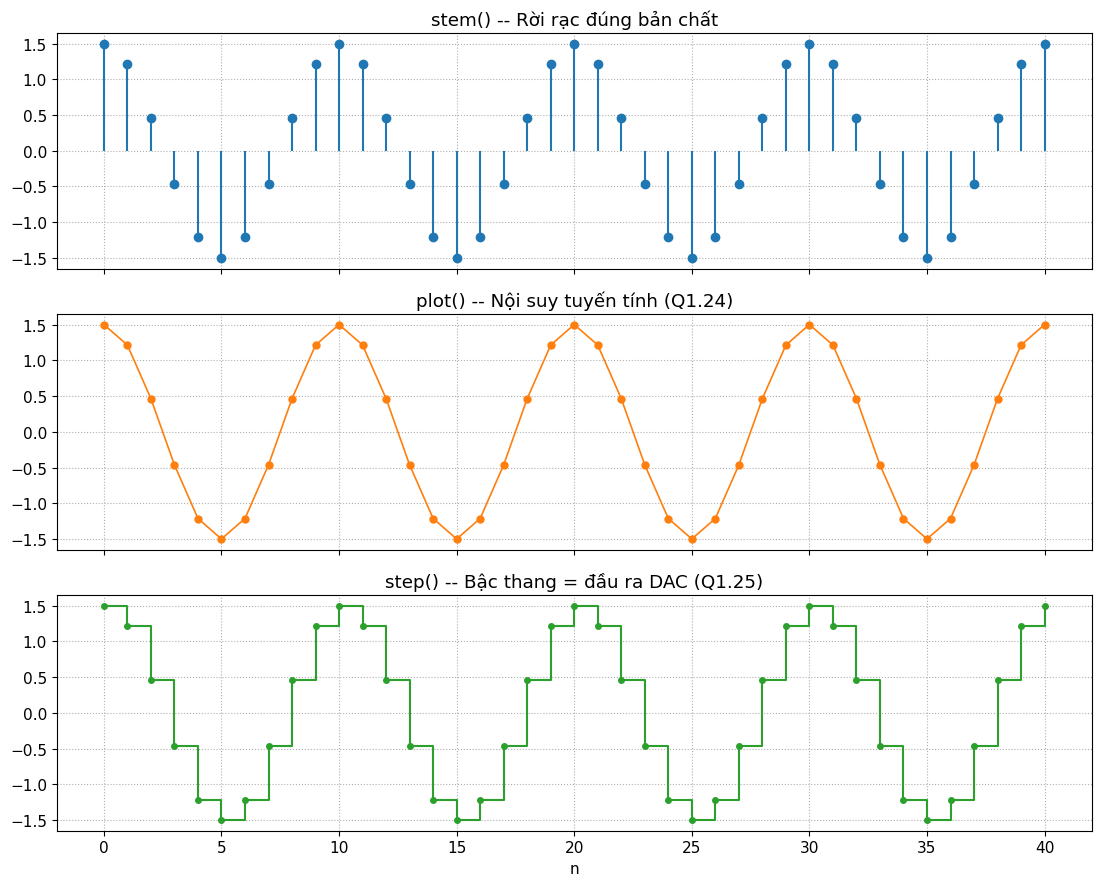

In [28]:
n = np.arange(0, 41); f = 0.1; A = 1.5
x = A * np.cos(2 * np.pi * f * n)

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

axes[0].stem(n, x, basefmt=' ', linefmt='C0-', markerfmt='C0o')
axes[0].set_title('stem() -- Rời rạc đúng bản chất')
axes[0].grid(True, linestyle=':')

axes[1].plot(n, x, 'C1o-', markersize=5, linewidth=1.2)
axes[1].set_title('plot() -- Nội suy tuyến tính (Q1.24)')
axes[1].grid(True, linestyle=':')

axes[2].step(n, x, where='post', color='C2', linewidth=1.5)
axes[2].plot(n, x, 'C2o', markersize=4)
axes[2].set_title('step() -- Bậc thang = đầu ra DAC (Q1.25)')
axes[2].set_xlabel('n'); axes[2].grid(True, linestyle=':')

plt.tight_layout(); plt.show()


### Bài tập nhỏ

1. Tạo dãy cos với $f = 1/6$ trên 20 mẫu. Chu kỳ là mấy mẫu?
2. So sánh $\cos(2\pi \cdot 0.3 n)$ với $\cos(2\pi \cdot 0.7 n)$: chúng có bằng nhau không? Giải thích.


---

## Project 1.4 -- Tín hiệu ngẫu nhiên

### Tại sao cần biết?

Mọi phép đo đều **có nhiễu**: điện từ trường, chuyển động cơ thể, rung lắc mạch. Mô hình hoá nhiễu là bước đầu tiên để:
- Đánh giá **SNR** (tỷ số tín hiệu/nhiễu).
- Thiết kế bộ lọc khử nhiễu.
- Phân biệt **phát hiện đúng** vs **phát hiện nhầm do nhiễu**.

### Hai phân phối cơ bản

**Uniform** $\mathcal{U}(a, b)$: mọi giá trị trong $[a, b]$ đều đồng xác suất. Trung bình $(a+b)/2$, phương sai $(b-a)^2/12$.

**Gaussian (normal)** $\mathcal{N}(\mu, \sigma^2)$: tập trung quanh trung bình, giảm dần theo đường chuông. Nhiều nhiễu tự nhiên tuân theo Gauss (ví dụ nhiễu Johnson trên điện trở).

### Q1.26 -- Uniform trong $[-2, 2]$ + histogram

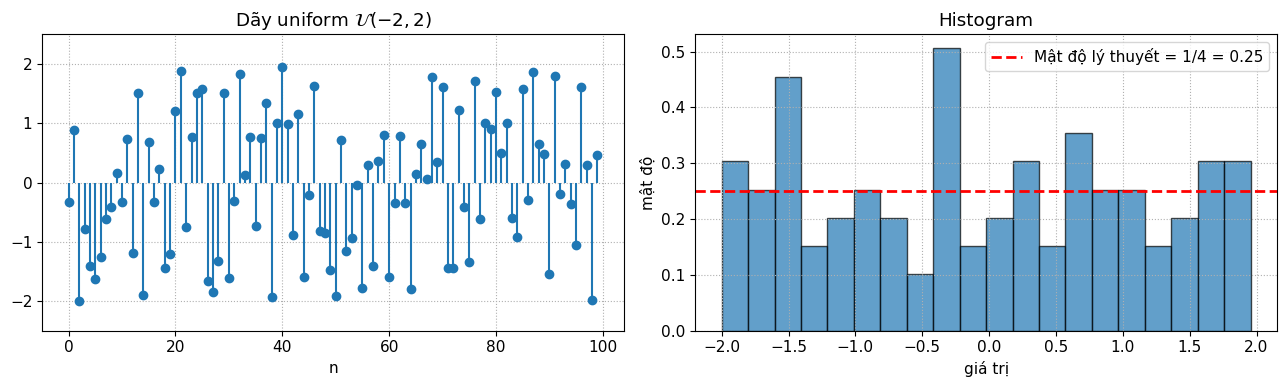

Trung bình mẫu : -0.056   (lý thuyết: 0)
Phương sai mẫu : 1.387   (lý thuyết: (2A)^2/12 = 1.333)


In [29]:
np.random.seed(1)
n = np.arange(100)
A = 2                                         # biên độ 2 -> khoảng [-2, 2]

# np.random.rand(n) sinh số uniform trong [0, 1)
# -> (rand - 0.5) trong [-0.5, 0.5) -> 2A*(...) trong [-A, A) = [-2, 2)
x_unif = 2 * A * (np.random.rand(len(n)) - 0.5)

# Vẽ cả dãy theo thời gian và histogram của các giá trị
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.stem(n, x_unif, basefmt=' ', linefmt='C0-', markerfmt='C0o')
ax1.set_title('Dãy uniform $\\mathcal{U}(-2, 2)$'); ax1.set_xlabel('n')
ax1.set_ylim(-2.5, 2.5); ax1.grid(True, linestyle=':')

ax2.hist(x_unif, bins=20, color='C0', edgecolor='k', alpha=0.7, density=True)
ax2.axhline(1/(2*A), color='r', linestyle='--', linewidth=2,
            label=f'Mật độ lý thuyết = 1/4 = {1/(2*A)}')
ax2.set_title('Histogram'); ax2.set_xlabel('giá trị'); ax2.set_ylabel('mật độ')
ax2.legend(); ax2.grid(True, linestyle=':')

plt.tight_layout(); plt.show()

# In thống kê
print(f'Trung bình mẫu : {np.mean(x_unif):.3f}   (lý thuyết: 0)')
print(f'Phương sai mẫu : {np.var(x_unif):.3f}   (lý thuyết: (2A)^2/12 = {(2*A)**2/12:.3f})')


Histogram phẳng **chứng thực** phân phối đều: mọi "cột" cao xấp xỉ bằng nhau. Với 100 mẫu, sai số vẫn còn; nếu tăng lên 10000 mẫu, histogram sẽ gần như chính xác bằng đường chấm đỏ.

### Q1.27 -- Gauss $\mathcal{N}(0, 3)$

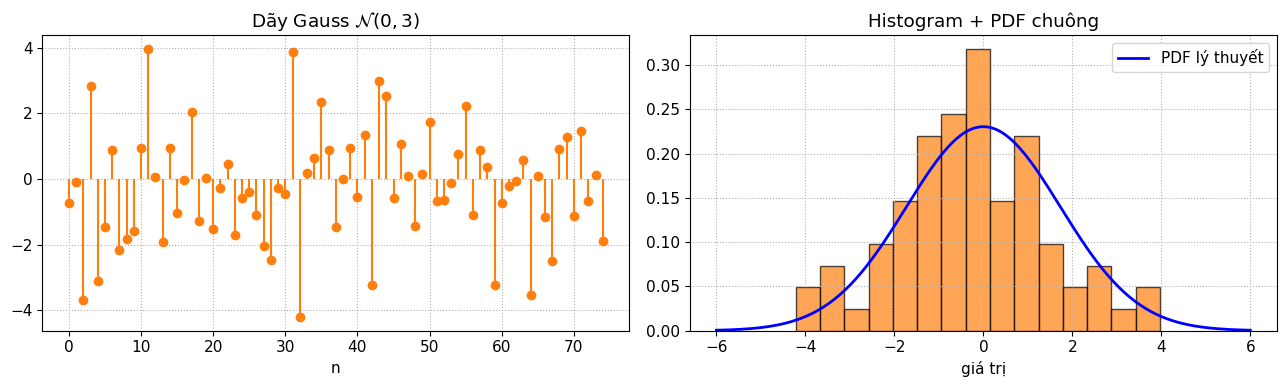

Trung bình mẫu: -0.259   (lý thuyết: 0)
Phương sai mẫu: 2.841   (lý thuyết: 3)


In [30]:
np.random.seed(2)
n     = np.arange(75)
xmean = 0.0                                   # trung bình
xvar  = 3.0                                   # phương sai
xstd  = np.sqrt(xvar)                         # độ lệch chuẩn

# randn(n) sinh số N(0, 1); nhân std, cộng mean để thành N(mean, std^2)
x_gauss = xstd * np.random.randn(len(n)) + xmean

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.stem(n, x_gauss, basefmt=' ', linefmt='C1-', markerfmt='C1o')
ax1.set_title('Dãy Gauss $\\mathcal{N}(0, 3)$')
ax1.set_xlabel('n'); ax1.grid(True, linestyle=':')

ax2.hist(x_gauss, bins=15, color='C1', edgecolor='k', alpha=0.7, density=True)
u = np.linspace(-6, 6, 200)
pdf = np.exp(-u**2/(2*xvar)) / np.sqrt(2*np.pi*xvar)
ax2.plot(u, pdf, 'b-', linewidth=2, label='PDF lý thuyết')
ax2.set_title('Histogram + PDF chuông'); ax2.set_xlabel('giá trị')
ax2.legend(); ax2.grid(True, linestyle=':')

plt.tight_layout(); plt.show()

print(f'Trung bình mẫu: {np.mean(x_gauss):.3f}   (lý thuyết: 0)')
print(f'Phương sai mẫu: {np.var(x_gauss):.3f}   (lý thuyết: 3)')


### Q1.28 -- Quá trình sin ngẫu nhiên

$X[n] = A \cos(2\pi f n + \phi)$ với $A \sim \mathcal{U}(0, 4)$ và $\phi \sim \mathcal{U}(0, 2\pi)$ độc lập. Mỗi thí nghiệm (trial) cho một **hiện thực** (realization) khác nhau.

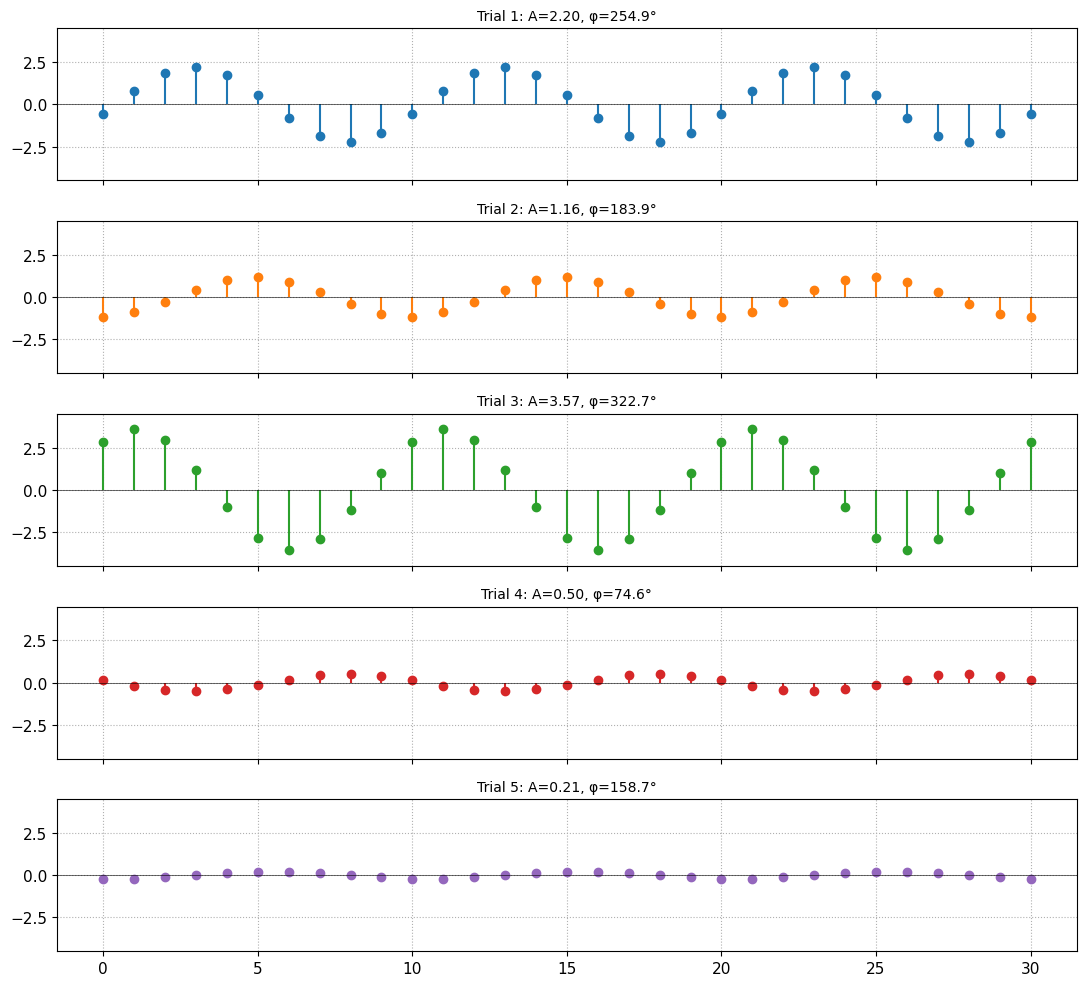

Nhận xét: cả 5 dãy có CHU KỲ 10 MẪU (do f = 0.1 cố định),
chỉ khác biên độ và pha khởi đầu.


In [31]:
np.random.seed(3)
n = np.arange(0, 31); f = 0.1; Amax = 4

fig, axes = plt.subplots(5, 1, figsize=(11, 10), sharex=True)
for trial in range(5):
    A   = Amax * np.random.rand()             # biên độ ngẫu nhiên trong [0, 4]
    phi = 2*np.pi * np.random.rand()          # pha ngẫu nhiên trong [0, 2π]
    x   = A * np.cos(2*np.pi*f*n + phi)
    axes[trial].stem(n, x, basefmt=' ', linefmt=f'C{trial}-', markerfmt=f'C{trial}o')
    axes[trial].set_title(f'Trial {trial+1}: A={A:.2f}, φ={np.degrees(phi):.1f}°', fontsize=10)
    axes[trial].set_ylim(-4.5, 4.5); axes[trial].grid(True, linestyle=':')
    axes[trial].axhline(0, color='k', linewidth=0.4)
plt.tight_layout(); plt.show()

print('Nhận xét: cả 5 dãy có CHU KỲ 10 MẪU (do f = 0.1 cố định),')
print('chỉ khác biên độ và pha khởi đầu.')


---

## Project 1.5 -- Làm trơn tín hiệu (Signal Smoothing)

### Tại sao cần biết?

Mọi tín hiệu y sinh (ECG, PPG, EEG) đều có nhiễu. Trung bình trượt 3 điểm là **bộ lọc đơn giản nhất** và thường đủ để cải thiện đáng kể chất lượng.

### Công thức

$$y[n] = \tfrac{1}{3} \big(x[n-1] + x[n] + x[n+1]\big)$$

Đây chính là **bộ lọc FIR bậc 2** với hệ số $h = [1/3, 1/3, 1/3]$.

### Thí nghiệm

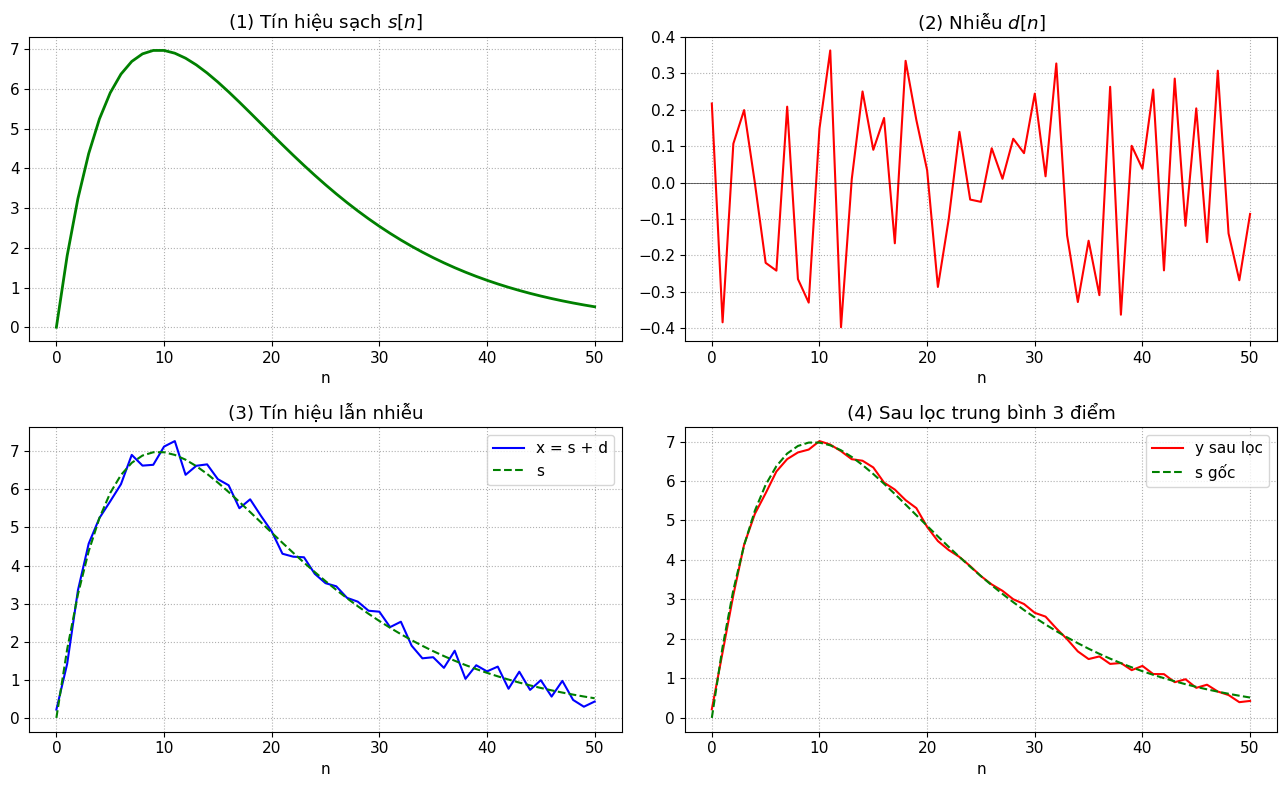

RMSE trước lọc: 0.2175
RMSE sau lọc : 0.1160  (giảm 46.7%)
SNR trước lọc: 25.49 dB
SNR sau  lọc : 30.95 dB  (tăng 5.46 dB)


In [32]:
np.random.seed(10)
R = 51
m = np.arange(R)

# Tín hiệu sạch: s[n] = 2n * 0.9^n (tăng tuyến tính nhân mũ giảm)
s = 2 * m * (0.9 ** m)

# Nhiễu uniform (-0.4, +0.4)
d = 0.8 * (np.random.rand(R) - 0.5)

# Tín hiệu có nhiễu
x = s + d

# Lọc trung bình 3 điểm
y = np.zeros_like(x)
# y[n] = (x[n-1] + x[n] + x[n+1]) / 3 cho n = 1..R-2
y[1:-1] = (x[:-2] + x[1:-1] + x[2:]) / 3
# Hai điểm biên: giữ nguyên (không đủ hàng xóm để lấy trung bình)
y[0]  = x[0]
y[-1] = x[-1]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].plot(m, s, 'g-', linewidth=2)
axes[0, 0].set_title('(1) Tín hiệu sạch $s[n]$')
axes[0, 0].set_xlabel('n'); axes[0, 0].grid(True, linestyle=':')

axes[0, 1].plot(m, d, 'r-')
axes[0, 1].axhline(0, color='k', linewidth=0.4)
axes[0, 1].set_title('(2) Nhiễu $d[n]$')
axes[0, 1].set_xlabel('n'); axes[0, 1].grid(True, linestyle=':')

axes[1, 0].plot(m, x, 'b-', label='x = s + d'); axes[1, 0].plot(m, s, 'g--', label='s')
axes[1, 0].set_title('(3) Tín hiệu lẫn nhiễu')
axes[1, 0].set_xlabel('n'); axes[1, 0].legend(); axes[1, 0].grid(True, linestyle=':')

axes[1, 1].plot(m, y, 'r-', label='y sau lọc'); axes[1, 1].plot(m, s, 'g--', label='s gốc')
axes[1, 1].set_title('(4) Sau lọc trung bình 3 điểm')
axes[1, 1].set_xlabel('n'); axes[1, 1].legend(); axes[1, 1].grid(True, linestyle=':')

plt.tight_layout(); plt.show()

# Định lượng: RMSE và SNR
rmse_before = np.sqrt(np.mean((x - s)**2))
rmse_after  = np.sqrt(np.mean((y - s)**2))
snr_before = 10*np.log10(np.mean(s**2) / np.mean((x-s)**2))
snr_after  = 10*np.log10(np.mean(s**2) / np.mean((y-s)**2))
print(f'RMSE trước lọc: {rmse_before:.4f}')
print(f'RMSE sau lọc : {rmse_after:.4f}  (giảm {100*(1 - rmse_after/rmse_before):.1f}%)')
print(f'SNR trước lọc: {snr_before:.2f} dB')
print(f'SNR sau  lọc : {snr_after:.2f} dB  (tăng {snr_after - snr_before:.2f} dB)')


Chỉ với 3 phép cộng và 1 phép chia, ta tăng SNR ~5 dB. Đây là lý do bộ lọc MA là "viên thuốc đầu tiên" mọi kỹ sư DSP dùng khi gặp nhiễu.

### Tại sao MA(3) là lowpass?

Đáp ứng tần số:

$$H(e^{j\omega}) = \tfrac{1}{3}(1 + 2\cos\omega)$$

$|H| = 1$ tại $\omega = 0$ (tín hiệu DC qua không suy giảm), $|H| = -1/3$ tại $\omega = \pi$ (tín hiệu nhanh bị ức chế).

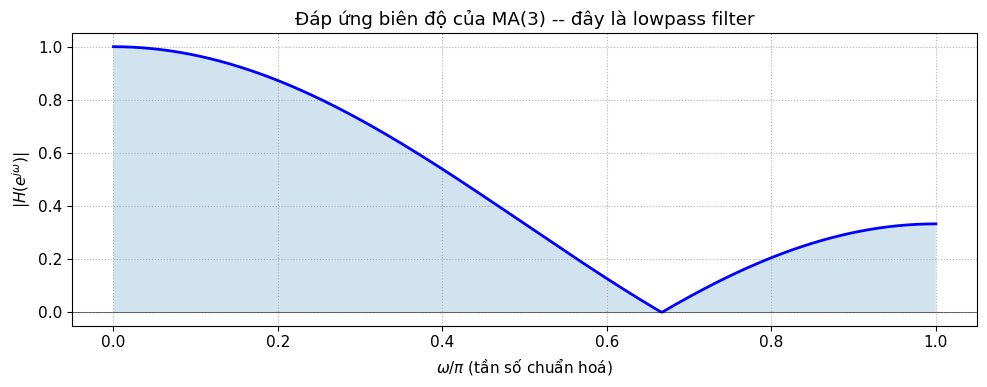

In [33]:
omega = np.linspace(0, np.pi, 512)
H = (1 + 2*np.cos(omega)) / 3

plt.figure(figsize=(10, 4))
plt.plot(omega/np.pi, np.abs(H), 'b-', linewidth=2)
plt.fill_between(omega/np.pi, 0, np.abs(H), alpha=0.2)
plt.axhline(0, color='k', linewidth=0.4)
plt.xlabel(r'$\omega/\pi$ (tần số chuẩn hoá)')
plt.ylabel(r'$|H(e^{j\omega})|$')
plt.title('Đáp ứng biên độ của MA(3) -- đây là lowpass filter')
plt.grid(True, linestyle=':'); plt.tight_layout(); plt.show()


---

## Project 1.6 -- Điều biên (Amplitude Modulation -- AM)

### Tại sao cần biết?

AM là **nguyên lý radio AM** (535-1605 kHz). Tiếng nói (thấp tần) được nhân với sóng mang (cao tần) để anten có thể bức xạ hiệu quả.

### Công thức

$$y[n] = \big(1 + m \cdot x_L[n]\big) \cdot x_H[n]$$

- $x_H[n]$: sóng **mang** (carrier), tần số cao.
- $x_L[n]$: sóng **điều chế** (modulating), tần số thấp, chứa thông tin.
- $m \in [0, 1]$: **chỉ số điều biên** -- $m$ càng lớn, "bao" càng rõ.

### Thí nghiệm với 4 cấu hình

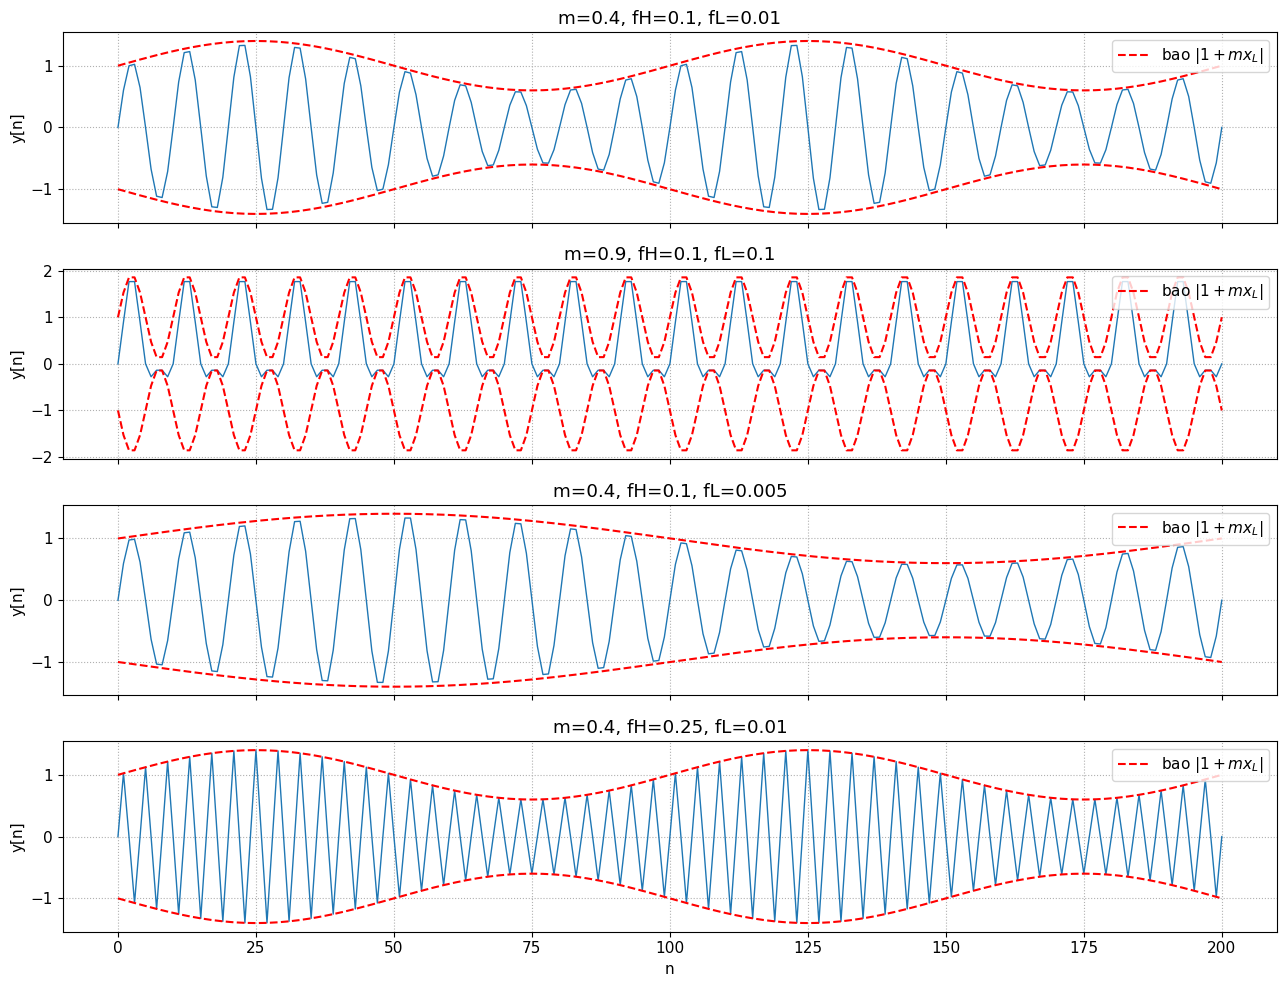

In [34]:
n = np.arange(0, 201)

configs = [
    dict(m=0.4, fH=0.1,  fL=0.01,  label='m=0.4, fH=0.1, fL=0.01'),
    dict(m=0.9, fH=0.1,  fL=0.1,   label='m=0.9, fH=0.1, fL=0.1'),
    dict(m=0.4, fH=0.1,  fL=0.005, label='m=0.4, fH=0.1, fL=0.005'),
    dict(m=0.4, fH=0.25, fL=0.01,  label='m=0.4, fH=0.25, fL=0.01'),
]

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
for i, cfg in enumerate(configs):
    xH = np.sin(2*np.pi*cfg['fH']*n)
    xL = np.sin(2*np.pi*cfg['fL']*n)
    y  = (1 + cfg['m']*xL) * xH
    envelope = np.abs(1 + cfg['m']*xL)         # đường bao

    axes[i].plot(n, y, 'C0-', linewidth=1)
    axes[i].plot(n,  envelope, 'r--', linewidth=1.5, label='bao $|1+mx_L|$')
    axes[i].plot(n, -envelope, 'r--', linewidth=1.5)
    axes[i].set_title(cfg['label']); axes[i].set_ylabel('y[n]')
    axes[i].legend(loc='upper right'); axes[i].grid(True, linestyle=':')
axes[-1].set_xlabel('n')
plt.tight_layout(); plt.show()


### Phổ của AM: ba đỉnh - sóng mang + 2 sideband

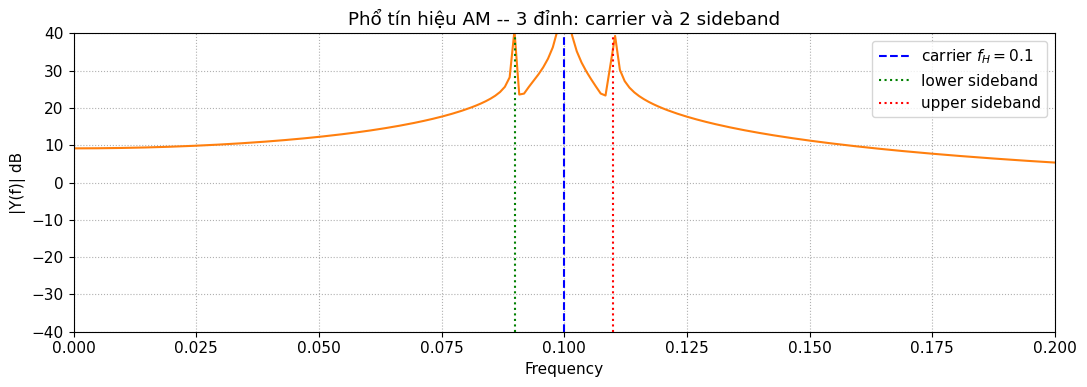

In [35]:
m, fH, fL = 0.4, 0.1, 0.01
n = np.arange(0, 1024)
y = (1 + m*np.sin(2*np.pi*fL*n)) * np.sin(2*np.pi*fH*n)

N = 1024
Y = fft(y, N)
freqs = fftfreq(N, d=1)[:N//2]
mag   = np.abs(Y[:N//2])

plt.figure(figsize=(11, 4))
plt.plot(freqs, 20*np.log10(mag + 1e-12), 'C1-')
plt.axvline(fH,      color='b', linestyle='--', label=f'carrier $f_H={fH}$')
plt.axvline(fH - fL, color='g', linestyle=':',  label=f'lower sideband')
plt.axvline(fH + fL, color='r', linestyle=':',  label=f'upper sideband')
plt.xlim(0, 0.2); plt.ylim(-40, 40)
plt.xlabel('Frequency'); plt.ylabel('|Y(f)| dB')
plt.title('Phổ tín hiệu AM -- 3 đỉnh: carrier và 2 sideband')
plt.legend(); plt.grid(True, linestyle=':'); plt.tight_layout(); plt.show()


---

## Project 1.7 -- Chirp (quét tần số)

### Tại sao cần biết?

Chirp (tín hiệu có tần số thay đổi theo thời gian) là tín hiệu cơ bản của **radar**, **sonar**, và **siêu âm y tế**. Ý tưởng: phát một chirp, bắt tín hiệu phản xạ, so sánh → đo được khoảng cách và vận tốc.

### Công thức

$$x[n] = \cos(an^2 + bn)$$

Tần số tức thời: $\omega_i[n] = 2an + b$ -- **tuyến tính** theo $n$.

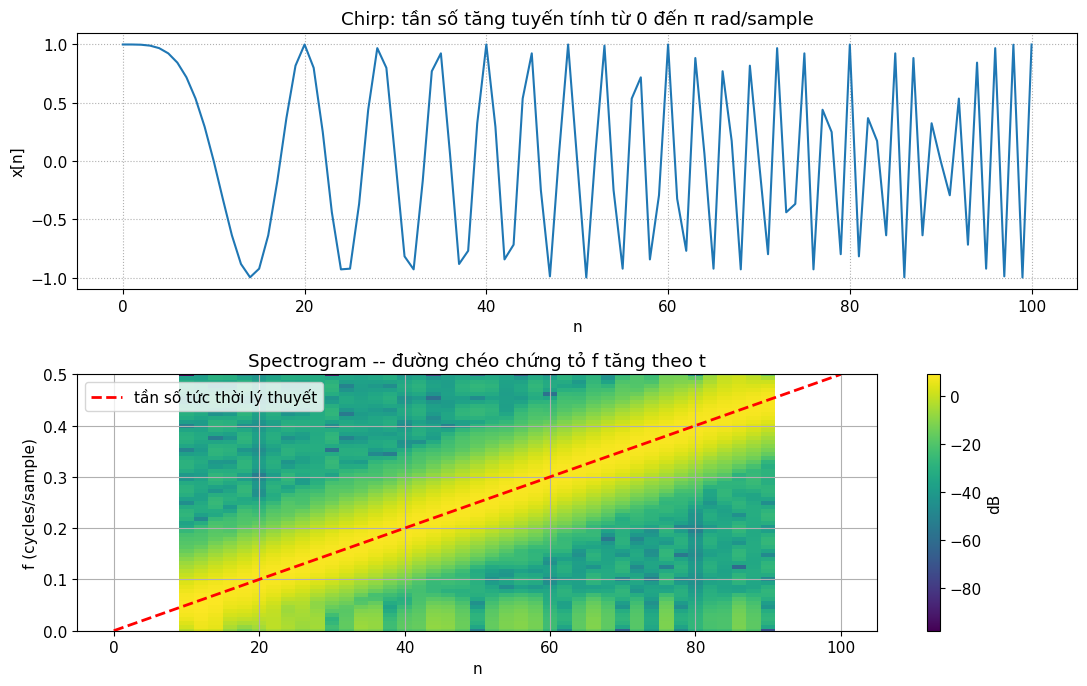

In [36]:
# P1_7: chirp từ 0 đến pi rad/sample
n = np.arange(0, 101)
a = np.pi / (2*100)
b = 0
x = np.cos(a*n*n + b*n)

# Vẽ miền thời gian + spectrogram (time-frequency)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7))

ax1.plot(n, x, 'C0-')
ax1.set_title('Chirp: tần số tăng tuyến tính từ 0 đến π rad/sample')
ax1.set_xlabel('n'); ax1.set_ylabel('x[n]'); ax1.grid(True, linestyle=':')

f_stft, t_stft, Sxx = signal.spectrogram(x, fs=1.0, nperseg=20, noverlap=18,
                                         nfft=128, window='hamming')
im = ax2.pcolormesh(t_stft, f_stft, 10*np.log10(Sxx + 1e-12),
                    cmap='viridis', shading='auto')

# Đường lý thuyết: tần số tức thời / (2pi) để đổi sang cycles/sample
n_theory = np.arange(101)
f_theory = (2*a*n_theory + b) / (2*np.pi)
ax2.plot(n_theory, f_theory, 'r--', linewidth=2, label='tần số tức thời lý thuyết')
ax2.set_xlabel('n'); ax2.set_ylabel('f (cycles/sample)')
ax2.set_ylim(0, 0.5); ax2.legend()
plt.colorbar(im, ax=ax2, label='dB')
ax2.set_title('Spectrogram -- đường chéo chứng tỏ f tăng theo t')

plt.tight_layout(); plt.show()


---

## Project 1.8 -- Sóng vuông, răng cưa, tam giác

### Tại sao cần biết?

- **Vuông**: xung clock số, PWM điều khiển động cơ, LED dimming.
- **Răng cưa**: quét CRT, VCO trong synth nhạc.
- **Tam giác**: sóng đơn giản mà vẫn "mượt hơn" vuông.

Tất cả đều là **tổng vô hạn các sin** (Fourier series).

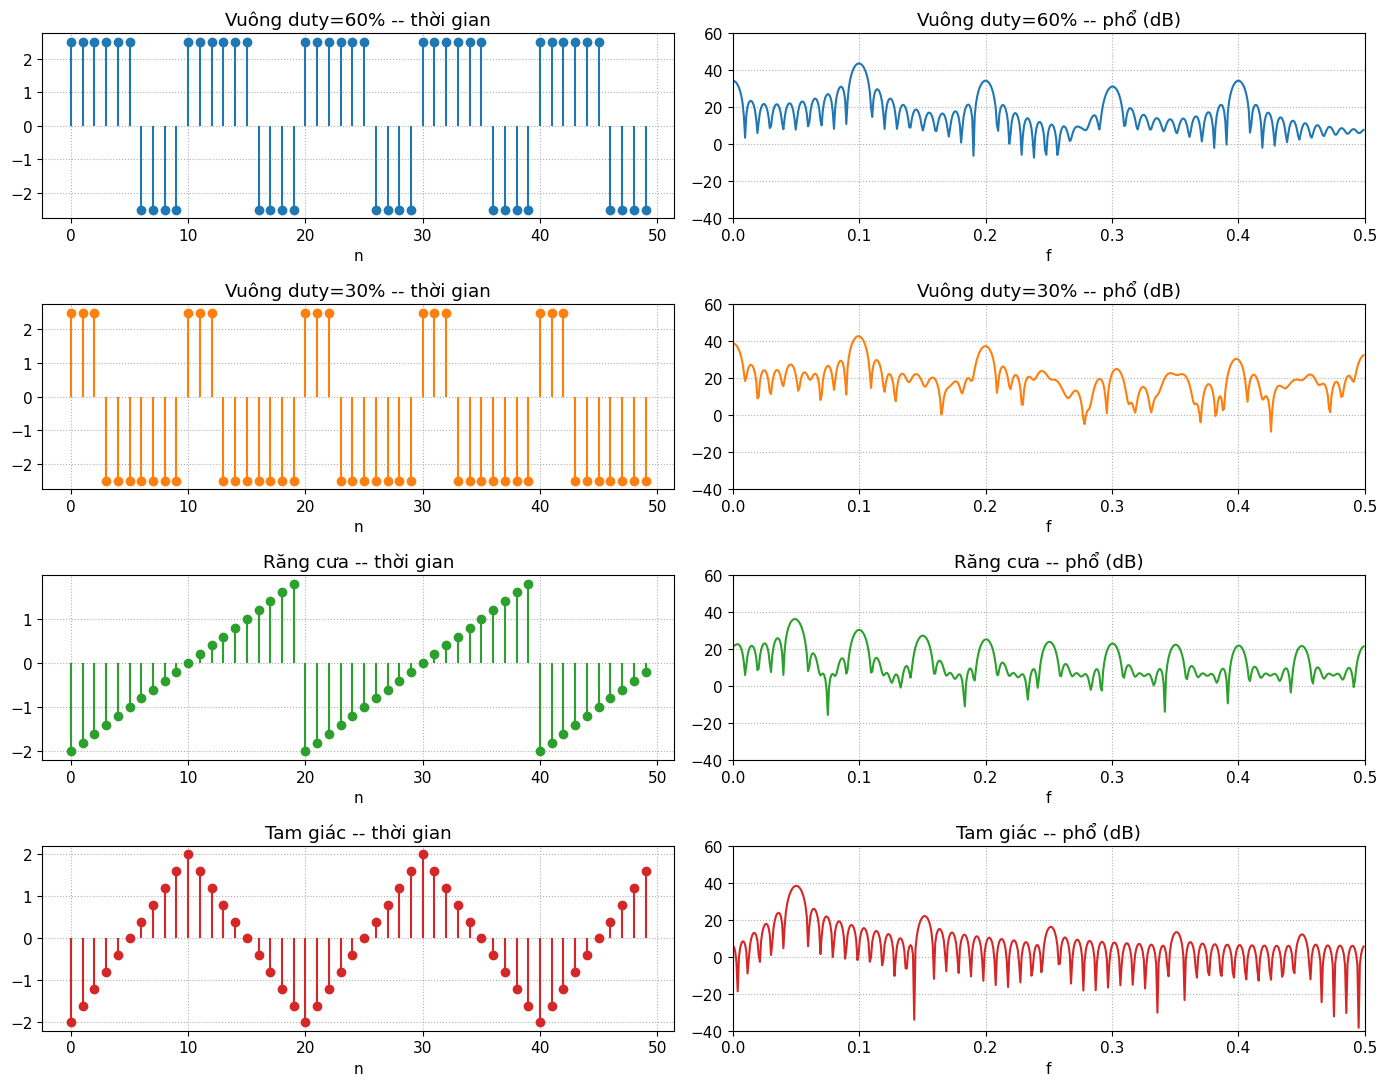

In [37]:
# 4 loại sóng: vuông 60%, vuông 30%, răng cưa, tam giác
# Kèm phổ để thấy chúng = tổng các sin
n = np.arange(0, 101)

sigs = [
    ('Vuông duty=60%', 2.5 * signal.square(2*np.pi*0.1*n, duty=0.60)),
    ('Vuông duty=30%', 2.5 * signal.square(2*np.pi*0.1*n, duty=0.30)),
    ('Răng cưa',       2.0 * signal.sawtooth(2*np.pi*0.05*n, width=1.0)),
    ('Tam giác',       2.0 * signal.sawtooth(2*np.pi*0.05*n, width=0.5)),
]

fig, axes = plt.subplots(4, 2, figsize=(14, 11))
for i, (name, x) in enumerate(sigs):
    axes[i, 0].stem(n[:50], x[:50], basefmt=' ', linefmt=f'C{i}-', markerfmt=f'C{i}o')
    axes[i, 0].set_title(f'{name} -- thời gian')
    axes[i, 0].set_xlabel('n'); axes[i, 0].grid(True, linestyle=':')

    N = 1024
    X = np.abs(fft(x, N))[:N//2]
    fr = fftfreq(N, d=1)[:N//2]
    axes[i, 1].plot(fr, 20*np.log10(X + 1e-12), f'C{i}-')
    axes[i, 1].set_title(f'{name} -- phổ (dB)')
    axes[i, 1].set_xlim(0, 0.5); axes[i, 1].set_ylim(-40, 60)
    axes[i, 1].set_xlabel('f'); axes[i, 1].grid(True, linestyle=':')

plt.tight_layout(); plt.show()


**Quan sát phổ**:
- Vuông: chỉ có **harmonic lẻ** ($f_0$, $3f_0$, $5f_0$, ...), biên độ giảm như $1/k$.
- Răng cưa: có **tất cả** harmonic, biên độ giảm như $1/k$.
- Tam giác: harmonic lẻ, biên độ giảm nhanh hơn ($1/k^2$) → sóng "mượt" hơn vuông.


# PHẦN C -- TỔNG KẾT VÀ BÀI TẬP

## Tổng kết 8 Project

| Project | Nội dung | Kỹ thuật Python đã học |
|---|---|---|
| 1.1 | Xung + bậc thang | `np.concatenate`, `np.zeros`, `np.ones` |
| 1.2 | Mũ thực & phức | `np.exp`, số phức với `1j`, `**` pointwise |
| 1.3 | Sin | `np.cos`, `np.sin`, `np.pi` |
| 1.4 | Ngẫu nhiên | `np.random.rand`, `np.random.randn`, `np.random.seed` |
| 1.5 | Smoothing MA(3) | slicing, vector arithmetic |
| 1.6 | AM | nhân điểm, `fft`, spectrogram |
| 1.7 | Chirp | polynomial phase, `signal.spectrogram` |
| 1.8 | Vuông/răng cưa | `signal.square`, `signal.sawtooth` |

## Các "điều phải nhớ" của Lab 1

1. **Tín hiệu rời rạc** $x[n]$ là **một dãy số** đánh chỉ số bởi $n$ nguyên.
2. **Python chỉ số bắt đầu từ 0**, không phải 1 như MATLAB.
3. **numpy vector hoá**: dùng `x * 2` thay vì vòng for.
4. **Chu kỳ cơ bản** của cos: $N_0 = 1/f$ (nếu $f$ hữu tỷ).
5. **Cyclic frequency**: $f$ và $1-f$ cho cùng dãy rời rạc (lý do của aliasing).
6. **Số phức** trong Python: `a + bj` với `j` (không phải `i` như toán).
7. **Trung bình trượt** là **lowpass filter** đơn giản nhất.

## Bài tập tổng hợp

### Bài 1 -- Tạo và biểu diễn

Tạo dãy $x[n]$ dài 100 mẫu:
$$x[n] = 2\cos(2\pi \cdot 0.05 n) + 0.5\sin(2\pi \cdot 0.12 n) + 0.3 r[n]$$

với $r[n] \sim \mathcal{N}(0, 1)$. Vẽ stem và đoán: tần số nào lấn át?

### Bài 2 -- Giảm nhiễu

Áp dụng bộ lọc MA(5) (trung bình 5 điểm) cho dãy ở Bài 1. So sánh SNR trước/sau.

### Bài 3 -- Tạo chirp cho ứng dụng radar

Tạo chirp từ $f = 0.05$ tới $f = 0.45$ trong 200 mẫu. Vẽ spectrogram. Tính $a$ và $b$.

### Bài 4 -- Phân tích nguyên âm

Ghi âm giọng "a" của chính bạn 1 giây ở 16 kHz (dùng điện thoại rồi import vào Colab). Thử áp dụng bộ lọc MA(3) xem âm thanh có thay đổi gì không.

## Chạy trên Google Colab

1. Upload file `.ipynb` này lên Google Drive.
2. Mở bằng Colab: `Runtime → Run all`.
3. Không cần cài thêm thư viện nào.

## Bước tiếp theo

- **Lab 2**: Tích chập và tương quan -- học cách xem hệ thống "phản ứng" với tín hiệu.
- **Lab 3**: Miền Z -- đào sâu vào đường xoắn ốc của dãy mũ phức.
- **Lab 4**: DFT/FFT -- phân tích phổ nhanh.

## Tài liệu

- Sanjit K. Mitra. *Digital Signal Processing: A Computer-Based Approach*. 4th ed. McGraw-Hill.
- Havlicek. Solution manual cho Mitra DSP -- bản PDF mà notebook này dịch sang Python.
- Oppenheim, A. V. & Schafer, R. W. *Discrete-Time Signal Processing*. 3rd ed. Pearson.
